In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rebound
import astropy.constants as const
import os 
import time
import netCDF4
import glob
from astropy import units as u
from multiprocessing import Pool
import json
import re
from plotting_params import use_my_style
from rebound import hash as rebound_hash
use_my_style()

## 40 AU Check

In [32]:
files = glob.glob(f'core_results/tracks*check.nc')

def read_files(filenames, n_planets):

    filecount = 0

    params = ['ecc', 'a', 'inc']
    all_data = {param: {0:[], 1:[]} for param in params}
    
    planet_as = []
    
    for index, file in enumerate(filenames):



        with netCDF4.Dataset(file, 'r') as ncfile:

            massive_bodies_a = ncfile['massive_bodies'][-1, 1:n_planets+1, 4]

                    
            massive_bodies_e = ncfile['massive_bodies'][-1, 1:n_planets+1, 3]

            dist = massive_bodies_a * (1+massive_bodies_e)
            dist_small = massive_bodies_a * ( 1 - massive_bodies_e)

            c1 = np.all(massive_bodies_e < 1)

            if n_planets == 2:
                c2 = ((dist[0] < dist_small[1]))
            if n_planets == 3:
                c2 = ((dist[2] < dist_small[0])) and (dist[0] < dist_small[1] ) 

            if c1 and c2: 

                print((ncfile['massive_bodies'][:, 1:n_planets+1, 4]))
   
                filecount += 1

                for param, index in zip(params, [3,4,5]):
                    t0 = ncfile['test_particles'][0,:,index].compressed()
                    t1 = ncfile['test_particles'][-1, :, index].compressed()
                    all_data[param][0].extend(t0)
                    all_data[param][1].extend(t1)

    for param in all_data:
        for t in (0,1):
            all_data[param][t] = [float(x) for x in all_data[param][t]]

    print(filecount)
    return all_data

In [33]:
all_data = read_files(filenames=files, n_planets=3)

for value in all_data['inc'][0]:
    if value < 0:
        print(value)

[[21.608511 35.722084 10.191081]
 [21.493393 35.72584  10.242086]]
[[21.608511 35.722084 10.191081]
 [22.292416 35.038616 10.226869]]
[[21.608511 35.722084 10.191081]
 [22.542526 35.056366 10.112919]]
[[21.608511 35.722084 10.191081]
 [20.997025 35.831062 10.407595]]
[[21.608511  35.722084  10.191081 ]
 [20.932243  35.461304  10.6458645]]
[[21.608511 35.722084 10.191081]
 [21.529394 35.72072  10.231554]]
[[21.608511 35.722084 10.191081]
 [21.576122 35.701717 10.203876]]
[[21.608511 35.722084 10.191081]
 [21.517973 35.61408  10.274714]]
[[21.608511 35.722084 10.191081]
 [22.37031  35.209507 10.120325]]
[[21.608511 35.722084 10.191081]
 [21.473133 35.690918 10.273433]]
[[21.608511 35.722084 10.191081]
 [21.243515 35.661026 10.389782]]
[[21.608511  35.722084  10.191081 ]
 [21.953903  35.49349   10.1640625]]
[[21.608511 35.722084 10.191081]
 [21.880465 35.6093   10.117597]]
[[21.608511 35.722084 10.191081]
 [21.77914  35.667088 10.135553]]
[[21.608511 35.722084 10.191081]
 [21.888859 35.60

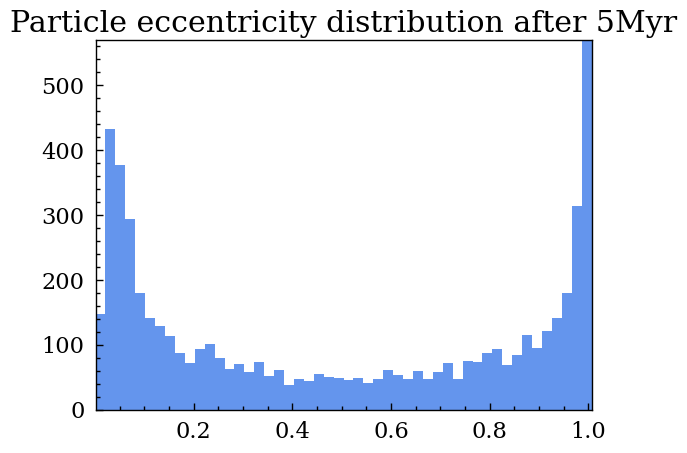

In [10]:
counts, _, _ = plt.hist(all_data['ecc'][1], bins=50, alpha=1,
                        label='t=5Myr',
                        color = 'cornflowerblue')
plt.title('Particle eccentricity distribution after 5Myr')
plt.show()

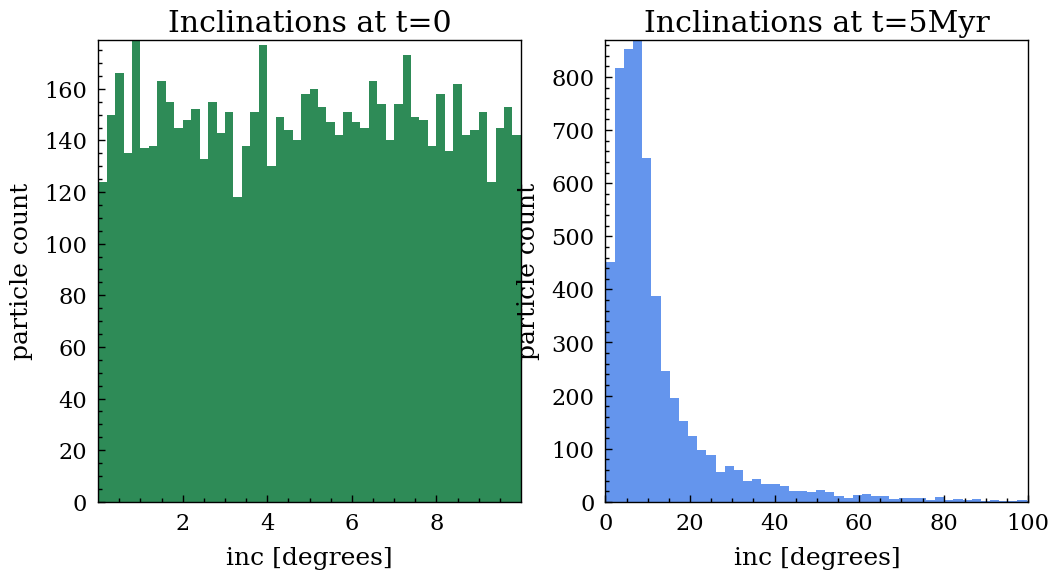

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12,6))

axes[0].hist([np.degrees(i) for i in all_data['inc'][0]], bins=50, color='seagreen')
axes[0].set_title('Inclinations at t=0')
axes[1].hist([np.degrees(e) for e in all_data['inc'][1]], bins=80, color='cornflowerblue')
axes[1].set_title('Inclinations at t=5Myr')
axes[1].set_xlim(0, 100)

for i in [0,1]:
    axes[i].set_xlabel('inc [degrees]')
    axes[i].set_ylabel('particle count')

plt.show()

Why are there no inclinations below 0 if I set them up to be between -10 and 10??

In [ ]:
all_data['a'][0]

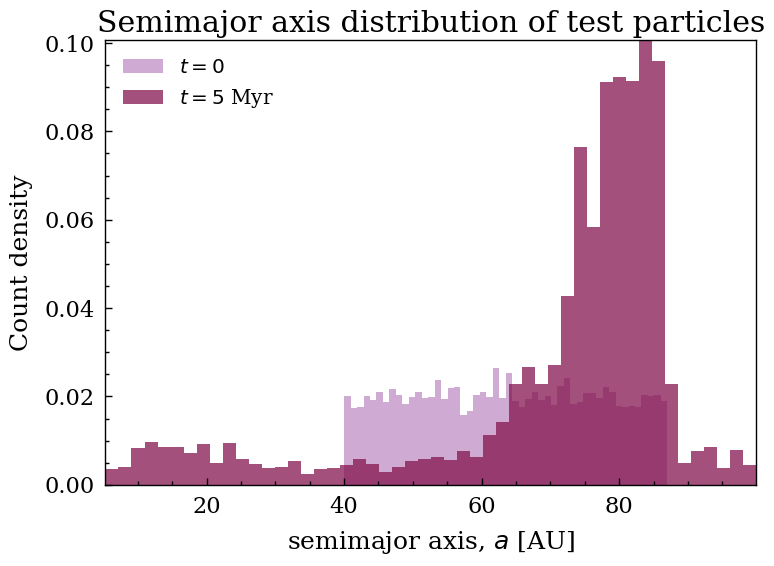

In [27]:
filtered_as = [x for x in all_data['a'][1] if (x <= 100 and x > 0)]

fig, axes = plt.subplots( figsize=(8,6))

color1 = "#841550FF" # darker purple
color2 = "#CAA1CD" # "#CAA1CD"
axes.hist(all_data['a'][0], bins=50, weights=np.ones_like(all_data['a'][0]) / len(all_data['a'][0]), color=color2, alpha=0.9, label=r'$t=0$', rasterized=True)
axes.hist(filtered_as, bins=50, weights=np.ones_like(filtered_as) / len(filtered_as), density=False, color=color1, alpha=0.75, label=r'$t=5$ Myr', rasterized = True)
#axes[0].set_title(r'$t=5$ Myr')


axes.set_xlabel(r'semimajor axis, $a$ [AU]')
axes.set_ylabel('Count density')
plt.title('Semimajor axis distribution of test particles')
plt.legend()
plt.tight_layout()
#plt.savefig('plots/semimajor_distribution_40AUcriterion.pdf')
plt.show()

## Dynamical timescale of PDS 70

In [ ]:
import astropy.constants as const
import astropy.units as u
import numpy as np

R_star = 1.185830 * const.R_sun
G = const.G
M = const.M_sun * 0.640

t_dy = np.sqrt(R_star**3/(G*M))
t_dy.to('s')



## Branching ratios (aline paper files)

In [2]:
# files3pl = glob.glob(f'aline_paper/*keep*.nc')
# files2pl = glob.glob(f'aline_paper/two_planet_stuff/*Star.nc')

two_pl_files_new = glob.glob(f'core_outputs_yr2/*10000_2_pl*saving*.nc')
three_pl_files_new = glob.glob(f'core_outputs_yr2/*10000_3_pl_*saving_every_100_yrs.nc')

print(len(two_pl_files_new), len(three_pl_files_new))

def read_files(filenames, n_planets, newformat = True):
    '''
    Reads the netCDF files and extracts the relevant data for the test particles, as well as the migrated, ejected, collided and captured particles.
    It also checks if the planets are stable (eccentricity < 1 and no orbit crossing) and only includes the files that are stable.
    '''

    filecount = 0

    params = ['ecc', 'a', 'inc', 'hash']
    all_data = {param: {0:[], 1:[]} for param in params}
    
    mig_data = {param: [] for param in ['time', 'hash']}
    
    ej_data = {param: [] for param in ['time', 'hash']}
    col_data = {param: [] for param in ['time', 'hash', 'planet']}
    capt_data = {param: [] for param in ['time', 'hash', 'planet']}

    for index, file in enumerate(filenames):

        with netCDF4.Dataset(file, 'r') as ncfile:

            ########### stability check ##############
            if newformat:
                massive_bodies_a = ncfile['test_particles'][-1, 0:n_planets, 5]
                massive_bodies_e = ncfile['test_particles'][-1, 0:n_planets, 4]

            else:
                if n_planets == 2:
                    massive_bodies_a = ncfile['massive_bodies'][-1, 1:n_planets+1,5]
                    massive_bodies_e = ncfile['massive_bodies'][-1, 1:n_planets+1,4]
                elif n_planets == 3:
                    massive_bodies_a = ncfile['massive_bodies'][-1, 1:n_planets+1,4]
                    massive_bodies_e = ncfile['massive_bodies'][-1, 1:n_planets+1,3]

            dist = massive_bodies_a * (1+massive_bodies_e)
            dist_small = massive_bodies_a * ( 1 - massive_bodies_e)

            c1 = np.all(massive_bodies_e < 1)

            if n_planets == 2:
                c2 = ((dist[0] < dist_small[1]))

            if not newformat:
                if n_planets == 3:
                    c2 = ((dist[2] < dist_small[0])) and (dist[0] < dist_small[1] ) 
            if newformat:
                if n_planets == 3:
                    c2 = ((dist[0] < dist_small[1])) and (dist[1] < dist_small[2] ) 

    
            ############ if stable, add the file and the particles ############
            if c1 and c2:    
                filecount += 1

                paramlist = [4,5,6,-1] if newformat else [3,4,5,-1]

                for param, index in zip(params, paramlist):
                    t0 = ncfile['test_particles'][0, n_planets:,index].compressed()
                    t1 = ncfile['test_particles'][-1, n_planets:, index].compressed()
                    all_data[param][0].extend(t0)
                    all_data[param][1].extend(t1)
                
                time = ncfile['migrated_peri'][:, 0].compressed()
                particle = ncfile['migrated_peri'][:, -1].compressed()
                mig_data['time'].extend(time)
                mig_data['hash'].extend(particle)

                ej_time = ncfile['ejected'][:, 0].compressed()
                ej_particle = ncfile['ejected'][:, -1].compressed()
                ej_data['time'].extend(ej_time)
                ej_data['hash'].extend(ej_particle)

                mig_hash_set = set(mig_data['hash'])

                filtered = [(t, h) for t, h in zip(ej_data['time'], ej_data['hash'])
                            if h not in mig_hash_set]

                if filtered:
                    ej_data['time'], ej_data['hash'] = map(list, zip(*filtered))
                else:
                    ej_data['time'], ej_data['hash'] = [], []

                col_time = ncfile['collided'][:,0].compressed()
                col_particle = ncfile['collided'][:,-2].compressed()
                col_data['time'].extend(col_time)
                col_data['hash'].extend(col_particle)
                col_data['planet'].extend(ncfile['collided'][:,-1].compressed())

                capt_time = ncfile['captured'][:,0].compressed()
                capt_particle = ncfile['captured'][:,-2].compressed()
                capt_data['time'].extend(capt_time)
                capt_data['hash'].extend(capt_particle)
                capt_data['planet'].extend(ncfile['captured'][:,-1].compressed())

               
    n_particles = len(all_data['a'][0])
    print(n_particles, 'particles')
    print('mig and ej', len(mig_data['hash']),len(ej_data['hash']))
    print('capt and col', len(capt_data['hash']), len(col_data['hash']))
    
    ####### turn everything into floats #########
    for param in all_data:
        for t in (0,1):
            all_data[param][t] = [float(x) for x in all_data[param][t]]

    return all_data, mig_data, ej_data, col_data, capt_data, n_particles

#read_files(two_pl_files_new, 2)

50 50


In [52]:
np.linspace(52, 90, 39)


array([52., 53., 54., 55., 56., 57., 58., 59., 60., 61., 62., 63., 64.,
       65., 66., 67., 68., 69., 70., 71., 72., 73., 74., 75., 76., 77.,
       78., 79., 80., 81., 82., 83., 84., 85., 86., 87., 88., 89., 90.])

100
10000 particles
mig and ej 1955 3205
capt and col 0 0
10000 particles in all_data
not unique []
10000
[ 1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
  1. nan]


/tmp/ipykernel_2898637/657348926.py:136: RuntimeWarning: invalid value encountered in divide
  stacked_counts = stacked_counts / bin_sums


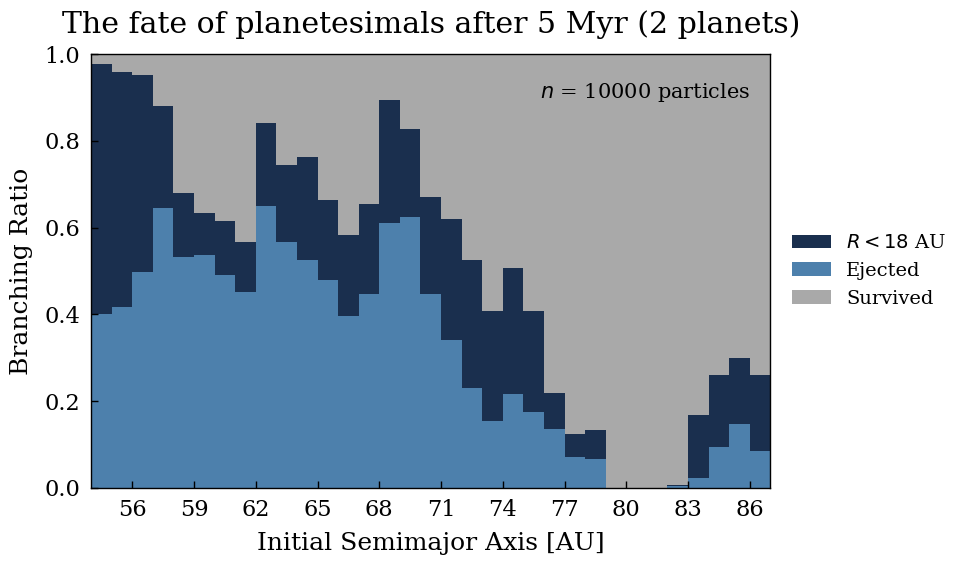

8200 particles
mig and ej 1180 1001
capt and col 0 0
8200 particles in all_data
not unique []
8200
[nan  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
 nan nan]


/tmp/ipykernel_2898637/657348926.py:136: RuntimeWarning: invalid value encountered in divide
  stacked_counts = stacked_counts / bin_sums


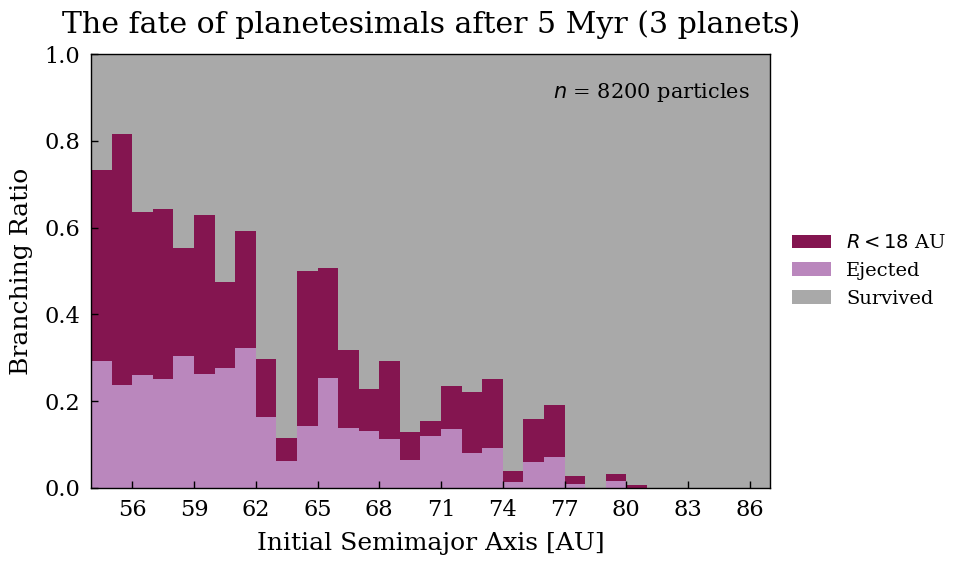

({'time': [2623588.75,
   2809971.75,
   3141507.75,
   3716821.25,
   4065683.5,
   4079633.75,
   4310657.0,
   4458830.0,
   4936949.5,
   1391015.875,
   1409818.0,
   1410225.875,
   1420546.875,
   1429756.25,
   1478306.625,
   1512131.25,
   1518223.25,
   1522071.875,
   1533843.875,
   1581938.25,
   1582041.25,
   1584068.125,
   1587612.25,
   1602484.875,
   1653614.625,
   1665170.5,
   1682974.25,
   1723171.5,
   1752709.875,
   1785342.25,
   1864501.625,
   1878471.625,
   1924221.25,
   1931862.125,
   1933519.5,
   1995761.875,
   2025474.5,
   2145144.25,
   2299898.0,
   2360940.5,
   2375966.25,
   2427049.0,
   2445277.0,
   2455990.0,
   2539949.0,
   2550605.0,
   2557104.25,
   2585052.0,
   2594649.25,
   2612182.0,
   2637546.25,
   2641893.5,
   2752069.5,
   2757549.5,
   2781336.5,
   2789449.75,
   2805145.0,
   2968281.5,
   2981980.0,
   3000738.0,
   3057169.0,
   3125581.75,
   3213221.75,
   3241046.5,
   3403449.0,
   3405105.75,
   3506429.0,
   

In [ ]:
from plotting_params import use_my_style
from collections import Counter
use_my_style()

def plot_outer_disc_particles(filename, n_planets, plot=True):
    loaded_data = read_files(filenames=filename, n_planets=n_planets)
    all_data = loaded_data[0]

    print(len(all_data['a'][0]), 'particles in all_data')
    mig_data = loaded_data[1]
    ej_data = loaded_data[2]
    col_data = loaded_data[3]
    capt_data = loaded_data[4]
    n_particles = loaded_data[-1]

    mig_dict = {k: [float(x) for x in v] for k, v in mig_data.items()}
    ej_dict = {k: [float(x) for x in v] for k, v in ej_data.items()}
    col_dict = {k: [float(x) for x in v] for k, v in col_data.items()}
    capt_dict = {k: [float(x) for x in v] for k, v in capt_data.items()}  

    # add new column to each dict for the initial semimajor axis of the particles  
    mig_dict['initial_a'] = [0] * len(mig_dict['hash'])
    ej_dict['initial_a'] = [0] * len(ej_dict['hash'])
    col_dict['initial_a'] = [0] * len(col_dict['hash'])
    capt_dict['initial_a'] = [0] * len(capt_dict['hash'])

    ########## for each category (mig, ej, capt, col), get init semimajor axis from the all_data dict using the hash as index ############
    
    #fOR EACH DICT, FIND THE CORRESPONDING INDEX!!
    for dictio in [ej_dict, col_dict, capt_dict, mig_dict]:
        for i, hval in enumerate(dictio['hash']):
            index = all_data['hash'][0].index(int(hval))
            initial_semimajoraxis = all_data['a'][0][index]
            dictio['initial_a'][i] = initial_semimajoraxis

    ############ get the initial semimajor axis and hash for all stable particles ############
    ej_hashes = np.array(ej_dict['hash'])
    mig_hashes = np.array(mig_dict['hash'])
    col_hashes = np.array(col_dict['hash'])

    if any(np.isin(col_hashes, mig_hashes)):
        print('Error! Some collided particles are also in the migrated list. This should not happen.')
    capt_hashes = np.array(capt_dict['hash'])

    ej_hashes   = ej_hashes[~np.isin(ej_hashes, mig_hashes)]
    col_hashes  = col_hashes[~np.isin(col_hashes, mig_hashes)]
    capt_hashes = capt_hashes[~np.isin(capt_hashes, mig_hashes)]

    if any(np.isin(col_hashes, mig_hashes)):
        print('Error! Some collided particles are also in the migrated list. This should not happen.')

    all_hashes = np.concatenate([ej_hashes, mig_hashes, col_hashes, capt_hashes])
    values, counts = np.unique(all_hashes, return_counts=True)

    not_unique = values[counts > 1]
    print('not unique', not_unique)

    all_bad_hashes = np.concatenate((ej_hashes, mig_hashes, col_hashes, capt_hashes))

    all_data['hash'][0] = np.array(all_data['hash'][0], dtype=np.int64)
    all_bad_hashes = np.array(all_bad_hashes, dtype=np.int64)    
    bad_hash_set = set(all_bad_hashes.tolist())

    hash_new, a_new = zip(*[
        (int(hashval), aval)
        for hashval, aval in zip(all_data['hash'][0], all_data['a'][0])
        if int(hashval) not in bad_hash_set
    ])

    # GET PLANET HASHES
    pb = rebound_hash('pb').value
    pc = rebound_hash('pc').value
    pd = rebound_hash('pd').value
    star = rebound_hash('star').value

    # SEPARATE DICTS BY TARGET
    collided_with = {'b': [], 'c': [], 'd': [], 'star': []}
    captured_by = {'b': [], 'c': [], 'd': []}

    # SEPARATE COLLISIONS
    for i, planet_hash in enumerate(col_dict['planet']):
        target = int(planet_hash)
        
        #FLOATS AREN'T SAVED WITH ENOUGH SIG. FIGURES
        if abs(target - pb) < 1000:
            collided_with['b'].append(col_dict['initial_a'][i])
        elif abs(target - pc) < 1000:
            collided_with['c'].append(col_dict['initial_a'][i])
        elif abs(target - pd) < 1000:
            collided_with['d'].append(col_dict['initial_a'][i])
        else:
            print(f'Error! Hash is none of the above. It is {target}. Star is {star}')

    # SEPARATE CAPTURES
    for i, planet_hash in enumerate(capt_dict['planet']):
        target = int(planet_hash)
        if abs(target - pb) < 1000:
            captured_by['b'].append(capt_dict['initial_a'][i])
        elif abs(target - pc) < 1000:
            captured_by['c'].append(capt_dict['initial_a'][i])
        elif abs(target - pd) < 1000:
            captured_by['d'].append(capt_dict['initial_a'][i])
        else:
            print(f'Error! Hash is none of the above. It is {target}')


    ############## start plotting #################
    if plot:
        fig, ax = plt.subplots(figsize=(10,6))
        bins = np.linspace(52, 90, 39)
        ejected_counts, _ = np.histogram(ej_dict['initial_a'], bins=bins)
        migrated_counts, _ = np.histogram(mig_dict['initial_a'], bins=bins)
        col_b_counts, _ = np.histogram(collided_with['b'], bins=bins)
        col_c_counts, _ = np.histogram(collided_with['c'], bins=bins)
        col_d_counts, _ = np.histogram(collided_with['d'], bins=bins)
        capt_b_counts, _ = np.histogram(captured_by['b'], bins=bins)
        capt_c_counts, _ = np.histogram(captured_by['c'], bins=bins)
        capt_d_counts, _ = np.histogram(captured_by['d'], bins=bins)
        all_others, _ = np.histogram(a_new, bins=bins)


        if n_planets==3:
            stacked_counts = np.vstack([ejected_counts, col_b_counts, col_c_counts, col_d_counts, 
                                        capt_b_counts, capt_c_counts, capt_d_counts, migrated_counts,
                                        all_others])
        elif n_planets==2:
            stacked_counts = np.vstack([ ejected_counts, col_b_counts, col_c_counts,
                                        capt_b_counts, capt_c_counts, migrated_counts,
                                        all_others])
            
        bin_sums = stacked_counts.sum(axis=0)
        print(np.sum(bin_sums))
        x = bins[:-1]
        width = 1
        bin_widths = np.diff(bins)
        stacked_counts = stacked_counts / bin_sums
        print(np.sum(stacked_counts, axis=0))
        bin_centers = 0.5 * (bins[1:] + bins[:-1])


        if n_planets == 3:
            colors = {
                'ejected_first':  "#A969AD",  # kept same light purple
                'col_b' : "#00CC66",   # vivid green (clean, bright)
                'col_c' : "#FFB000" ,  # amber (better than yellow, less washed out)
                'col_d' :"#00BFEF" ,    # rose pink
                'capt_b': '#4a72b0',    # medium blue
                'capt_c': '#2a9d8f',    # teal
                'capt_d': '#56b4e9',    # sky blue
                'migrated': '#841550FF',  # kept same deep pinkish-purple
                'stable_first': 'darkgrey',
            }
        elif n_planets == 2:
                colors = {
            'col_b' : "#00CC66",   # vivid green (clean, bright)
            'col_c' : "#FFB000" ,  # amber (better than yellow, less washed out)
            'capt_b': '#0f52ba',      # sapphire blue
            'capt_c': '#00a1b0',      # vibrant cyan-teal
            'migrated': '#1a2f4e',      # navy blue (darker, distinct)
            'stable_first': 'darkgrey',
            'ejected_first':  "#206197",
        }

        bottom = np.zeros(len(x))

        if np.nansum(stacked_counts[0]) > 0:

            plt.bar(x, stacked_counts[0], width=1, bottom=bottom,
                    alpha=0.8, label=r"Ejected", color=colors['ejected_first'], align='edge', rasterized=True)
            bottom += stacked_counts[0]

        if n_planets == 3:
            # COLLISIONS
            for i, (label, count_idx) in enumerate([('Collided with b', 1), ('Collided with c', 2), 
                                                    ('Collided with d', 3)]):
                if np.nansum(stacked_counts[count_idx]) > 0:
                    ax.bar(x, stacked_counts[count_idx], width=bin_widths, bottom=bottom,
                            alpha=0.8, label=label, color=colors[f'col_{label.split()[-1]}'], align='edge', rasterized=True)
                    bottom += stacked_counts[count_idx]
            
            # CAPTURES
            for i, (label, count_idx) in enumerate([('Captured by b', 4), ('Captured by c', 5), ('Captured by d', 6)]):
                if np.nansum(stacked_counts[count_idx]) > 0:
                    ax.bar(x, stacked_counts[count_idx], width=bin_widths, bottom=bottom,
                            alpha=0.8, label=label, color=colors[f'capt_{label.split()[-1]}'], align='edge', rasterized=True)
                    bottom += stacked_counts[count_idx]

        elif n_planets == 2:

            # COLLISIONS
            for i, (label, count_idx) in enumerate([('Collided with b', 1), ('Collided with c', 2)]):
                if np.nansum(stacked_counts[count_idx]) > 0:
                    ax.bar(x, stacked_counts[count_idx], width=bin_widths, bottom=bottom,
                            alpha=0.85, label=label, color=colors[f'col_{label.split()[-1]}'], align='edge', rasterized=True)
                    bottom += stacked_counts[count_idx]
   
            # CAPTURES
            for i, (label, count_idx) in enumerate([('Captured by b', 3), ('Captured by c', 4)]):
                if np.nansum(stacked_counts[count_idx]) > 0:
                    ax.bar(x, stacked_counts[count_idx], width=bin_widths, bottom=bottom,
                            alpha=0.85, label=label, color=colors[f'capt_{label.split()[-1]}'], align='edge', rasterized=True)
                    bottom += stacked_counts[count_idx]

        if np.nansum(stacked_counts[-2]) > 0:
            ax.bar(x, stacked_counts[-2], width=bin_widths, bottom=bottom,
                    alpha=1, label=r"$R < 18$ AU", color=colors['migrated'], align='edge', rasterized=True)
            bottom += stacked_counts[-2]

        if np.nansum(stacked_counts[-1]) > 0:
            ax.bar(x, stacked_counts[-1], width=bin_widths, bottom=bottom,
                    alpha=1, label="Survived", color=colors['stable_first'], align='edge', rasterized=True)
            bottom += stacked_counts[-1]

        ax.minorticks_off()
        tick_idx = np.arange(1, len(bins), 3)
        ax.set_xticks(bins[tick_idx])
        ax.set_xticklabels([f"{b:.0f}" for b in bins[tick_idx]])

        plt.text(86, 0.9, rf'$n$ = {np.sum(bin_sums)} particles', color='k', ha='right', fontsize=15)
        plt.xlabel('Initial Semimajor Axis [AU]')
        plt.ylabel('Branching Ratio')
        plt.title(f'The fate of planetesimals after 5 Myr ({n_planets} planets)', y=1.03)
        plt.xlim(54, 87)

        handles, labels = ax.get_legend_handles_labels()

        if n_planets == 3:
            order = [1, 0, 2]
        else:
            order = [1, 0, 2]  

        ax.legend(
            [handles[i] for i in order],
            [labels[i] for i in order],

            loc='center left',
            bbox_to_anchor=(1.02, 0.5),
            borderaxespad=0,
            frameon=False,
            fontsize=14  # Slightly smaller due to more legend items
        )
        plt.tight_layout()
        plt.savefig(f'plots/branching_ratio_{n_planets}_pl_simple_with_captures.png')
        plt.savefig(f'plots/branching_ratio_{n_planets}_pl_simple_with_captures.pdf')
        plt.show()

    # return mig_dict for gas drag analysis later
    return mig_dict, ej_dict, col_dict, capt_dict, a_new, n_particles


final_sim_2_pl_files = [f for f in glob.glob(f'core_outputs_yr2/*50000_2_pl_w_captures*') if 'failed' not in f]
print(len(final_sim_2_pl_files))
plot_outer_disc_particles(two_pl_files_new, 2)
plot_outer_disc_particles(three_pl_files_new, 3)

## Only mig later (outer disc)

10000 particles
mig and ej 1955 3205
capt and col 0 0
10000 total particles in bins
[ 36 156 270 238 247 292 357 335 298 293 282 386 278 297 300 306 375 256
 242 320 345 311 304 270 297 284 314 372 302 352 308 269 266 177 154 108
   3]
7692 total particles in bins
[  4  13  29  51  78 131 222 224 208 218 208 265 167 235 228 221 224 183
 231 260 287 275 266 258 297 284 314 372 302 352 308 269 266 177 154 108
   3]


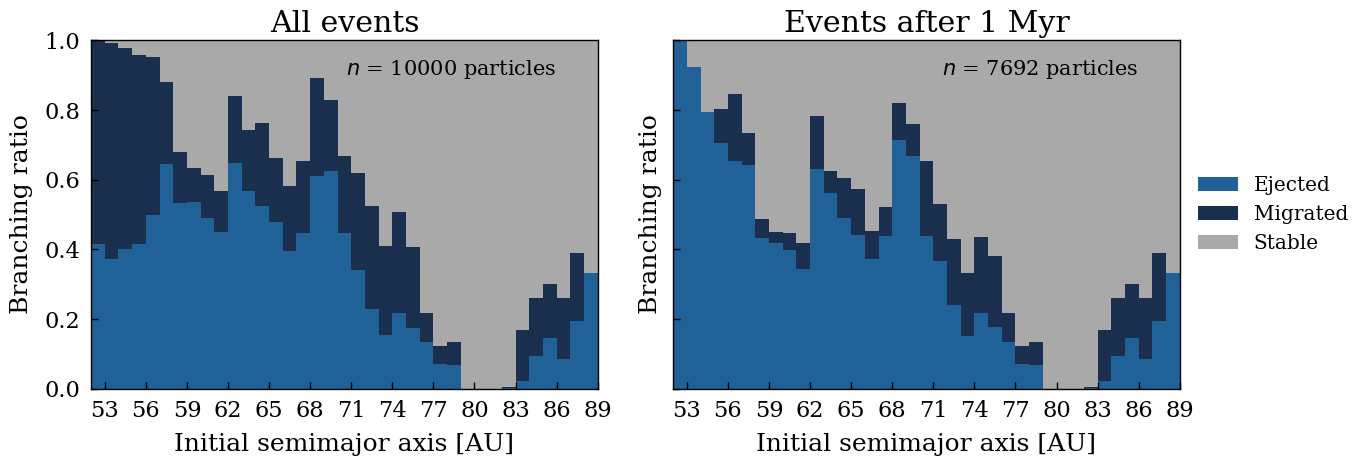

8200 particles
mig and ej 1180 1001
capt and col 0 0
8200 total particles in bins
[  0  96 257 212 184 336 345 172 280 292 276 148  14 150 300 245 359 282
 279 372 176 196 228 182 324 219 381 325 268 213 217 210 196 227 192  47]


/tmp/ipykernel_2898637/78160882.py:93: RuntimeWarning: invalid value encountered in divide
  stacked = stacked / bin_sums


8006 total particles in bins
[  0  66 212 150 161 317 343 172 276 289 276 148  14 150 300 245 359 282
 279 371 173 194 228 182 324 219 381 325 268 213 217 210 196 227 192  47]


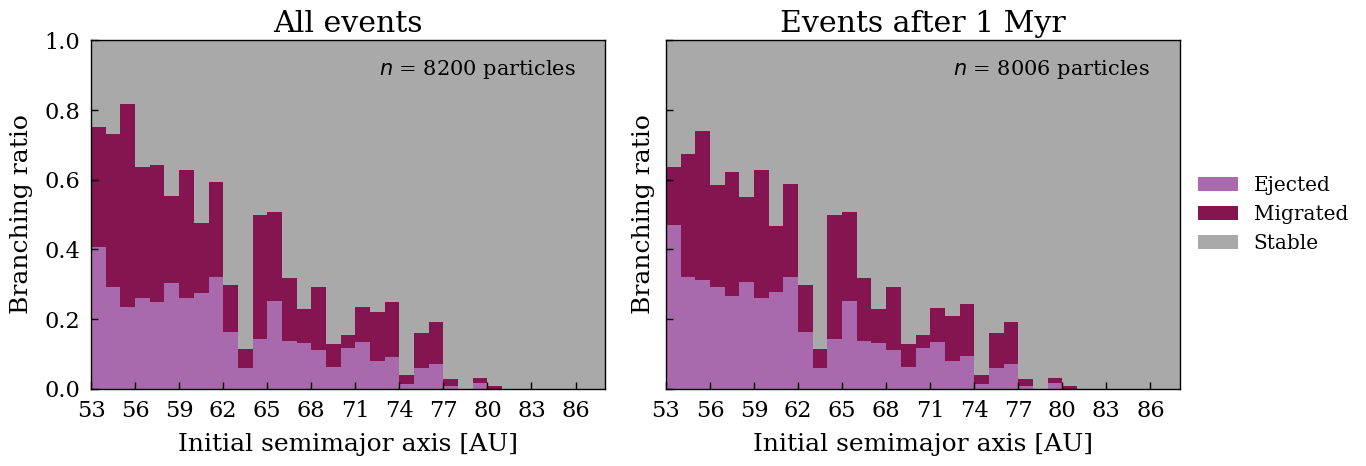

In [89]:
import numpy as np
import matplotlib.pyplot as plt


# ---------- helpers ----------

def add_initial_a(dicts, all_data):
    for d in dicts:
        d['initial_a'] = [0] * len(d['hash'])
        for i, hval in enumerate(d['hash']):
            index = all_data['hash'][0].index(int(hval))
            d['initial_a'][i] = all_data['a'][0][index]


def filter_by_time_copy(d, tmin):
    times = np.array(d['time'])  # adjust key if needed
    mask = times > tmin
    return {k: np.array(v)[mask] for k, v in d.items()}


def remove_mig_overlap(ej, col, capt, mig):
    mig_hashes = np.array(mig['hash'])
    for d in [ej, col, capt]:
        mask = ~np.isin(d['hash'], mig_hashes)
        for k in d:
            d[k] = np.array(d[k])[mask]


def compute_stacked_counts(ej_dict, mig_dict, col_dict, capt_dict,
                           all_data, a_new, bins, n_planets):

    # --- separate by planet ---
    pb = rebound_hash('pb').value
    pc = rebound_hash('pc').value
    pd = rebound_hash('pd').value

    collided_with = {'b': [], 'c': [], 'd': []}
    captured_by = {'b': [], 'c': [], 'd': []}

    for i, planet_hash in enumerate(col_dict['planet']):
        target = int(planet_hash)
        if abs(target - pb) < 1000:
            collided_with['b'].append(col_dict['initial_a'][i])
        elif abs(target - pc) < 1000:
            collided_with['c'].append(col_dict['initial_a'][i])
        elif abs(target - pd) < 1000:
            collided_with['d'].append(col_dict['initial_a'][i])

    for i, planet_hash in enumerate(capt_dict['planet']):
        target = int(planet_hash)
        if abs(target - pb) < 1000:
            captured_by['b'].append(capt_dict['initial_a'][i])
        elif abs(target - pc) < 1000:
            captured_by['c'].append(capt_dict['initial_a'][i])
        elif abs(target - pd) < 1000:
            captured_by['d'].append(capt_dict['initial_a'][i])

    # --- histograms ---
    ejected_counts, _ = np.histogram(ej_dict['initial_a'], bins=bins)
    migrated_counts, _ = np.histogram(mig_dict['initial_a'], bins=bins)

    col_b_counts, _ = np.histogram(collided_with['b'], bins=bins)
    col_c_counts, _ = np.histogram(collided_with['c'], bins=bins)
    col_d_counts, _ = np.histogram(collided_with['d'], bins=bins)

    capt_b_counts, _ = np.histogram(captured_by['b'], bins=bins)
    capt_c_counts, _ = np.histogram(captured_by['c'], bins=bins)
    capt_d_counts, _ = np.histogram(captured_by['d'], bins=bins)

    all_others, _ = np.histogram(a_new, bins=bins)

    # --- stack ---
    if n_planets == 3:
        stacked = np.vstack([
            ejected_counts,
            col_b_counts, col_c_counts, col_d_counts,
            capt_b_counts, capt_c_counts, capt_d_counts,
            migrated_counts,
            all_others
        ])
    else:
        stacked = np.vstack([
            ejected_counts,
            col_b_counts, col_c_counts,
            capt_b_counts, capt_c_counts,
            migrated_counts,
            all_others
        ])

    # normalize
    bin_sums = stacked.sum(axis=0)
    print(np.sum(bin_sums), 'total particles in bins')
    stacked = stacked / bin_sums

    print(bin_sums)
    return stacked, bin_sums


def plot_stacked(ax, stacked, bins, n_planets, title):
    x = bins[:-1]
    widths = np.diff(bins)
    bottom = np.zeros_like(x)



    labels = []

    if n_planets == 3:
        colors = {
            'ejected':  "#A969AD",  # kept same light purple
            'col_b' : "#00CC66",   # vivid green (clean, bright)
            'col_c' : "#FFB000" ,  # amber (better than yellow, less washed out)
            'col_d' :"#00BFEF" ,    # rose pink
            'capt_b': '#4a72b0',    # medium blue
            'capt_c': '#2a9d8f',    # teal
            'capt_d': '#56b4e9',    # sky blue
            'mig': '#841550FF',  # kept same deep pinkish-purple
            'stable': 'darkgrey',
        }
        labels = [
            ('Ejected', 'ejected'),
            ('Collided b', 'col_b'),
            ('Collided c', 'col_c'),
            ('Collided d', 'col_d'),
            ('Captured b', 'capt_b'),
            ('Captured c', 'capt_c'),
            ('Captured d', 'capt_d'),
            ('Migrated', 'mig'),
            ('Stable', 'stable')
        ]
    else:
        colors = {
        'col_b' : "#00CC66",   # vivid green (clean, bright)
        'col_c' : "#FFB000" ,  # amber (better than yellow, less washed out)
        'capt_b': '#0f52ba',      # sapphire blue
        'capt_c': '#00a1b0',      # vibrant cyan-teal
        'mig': '#1a2f4e',      # navy blue (darker, distinct)
        'stable': 'darkgrey',
        'ejected':  "#206197",
    }
        labels = [
            ('Ejected', 'ejected'),
            ('Collided b', 'col_b'),
            ('Collided c', 'col_c'),
            ('Captured b', 'capt_b'),
            ('Captured c', 'capt_c'),
            ('Migrated', 'mig'),
            ('Stable', 'stable')
        ]

    for i, (lab, key) in enumerate(labels):
        if np.nansum(stacked[i]) > 0:
            ax.bar(x, stacked[i], width=widths, bottom=bottom,
                   label=lab, color=colors[key], align='edge', rasterized=True)
            bottom += stacked[i]


    ax.set_title(title)
    ax.minorticks_off()
    tick_idx = np.arange(1, len(bins), 3)
    ax.set_xticks(bins[tick_idx])
    ax.set_xticklabels([f"{b:.0f}" for b in bins[tick_idx]])

    #ax.set_xlim(54, 87)
    ax.set_xlabel('Initial semimajor axis [AU]')
    ax.set_ylabel('Branching ratio')


# ---------- main ----------

def plot_outer_disc_particles(filename, n_planets):

    loaded = read_files(filename, n_planets)
    all_data = loaded[0]

    mig_dict = {k: [float(x) for x in v] for k, v in loaded[1].items()}
    ej_dict  = {k: [float(x) for x in v] for k, v in loaded[2].items()}
    col_dict = {k: [float(x) for x in v] for k, v in loaded[3].items()}
    capt_dict= {k: [float(x) for x in v] for k, v in loaded[4].items()}

    # add initial a
    add_initial_a([mig_dict, ej_dict, col_dict, capt_dict], all_data)

    # remove overlaps
    remove_mig_overlap(ej_dict, col_dict, capt_dict, mig_dict)

    # stable particles
    all_hashes = np.concatenate([
        ej_dict['hash'], mig_dict['hash'],
        col_dict['hash'], capt_dict['hash']
    ])

    bad_set = set(np.array(all_hashes, dtype=np.int64))
    hash_new, a_new = zip(*[
        (h, a) for h, a in zip(all_data['hash'][0], all_data['a'][0])
        if int(h) not in bad_set
    ])

    max_bin, min_bin = np.max(all_data['a'][0]), np.min(all_data['a'][0])
    bins = np.arange(round(min_bin)-1, round(max_bin, 1)+1, 1)

    # --- full ---
    stacked_full, bin_sums_full = compute_stacked_counts(
        ej_dict, mig_dict, col_dict, capt_dict,
        all_data, a_new, bins, n_planets
    )

    # --- filtered (>1 Myr) ---
    tmin = 1e6
    mig_f = filter_by_time_copy(mig_dict, tmin)
    ej_f  = filter_by_time_copy(ej_dict, tmin)
    col_f = filter_by_time_copy(col_dict, tmin)
    capt_f= filter_by_time_copy(capt_dict, tmin)

    add_initial_a([mig_f, ej_f, col_f, capt_f], all_data)

    stacked_filt, bin_sums_filt = compute_stacked_counts(
        ej_f, mig_f, col_f, capt_f,
        all_data, a_new, bins, n_planets
    )

    # --- plot ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    plot_stacked(axes[0], stacked_full, bins, n_planets, "All events")
    plot_stacked(axes[1], stacked_filt, bins, n_planets, "Events after 1 Myr")
    axes[0].text(86, 0.9, rf'$n$ = {np.sum(bin_sums_full)} particles', color='k', ha='right', fontsize=15)
    axes[1].text(86, 0.9, rf'$n$ = {np.sum(bin_sums_filt)} particles', color='k', ha='right', fontsize=15)

    axes[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.tight_layout()
    plt.savefig(f'plots/branching_ratio_{n_planets}_pl_full_vs_mig_later.pdf')
    plt.show()

plot_outer_disc_particles(two_pl_files_new, 2)
plot_outer_disc_particles(three_pl_files_new, 3)

In [ ]:
from plotting_params import use_my_style
from collections import Counter
use_my_style()

def make_hists(filename, n_planets, plot=True):
    loaded_data = read_files(filenames=filename, n_planets=n_planets)
    all_data = loaded_data[0]

    mig_data = loaded_data[1]
    ej_data = loaded_data[2]
    col_data = loaded_data[3]
    capt_data = loaded_data[4]
    n_particles = loaded_data[-1]

    mig_dict = {k: [float(x) for x in v] for k, v in mig_data.items()}
    ej_dict = {k: [float(x) for x in v] for k, v in ej_data.items()}
    col_dict = {k: [float(x) for x in v] for k, v in col_data.items()}
    capt_dict = {k: [float(x) for x in v] for k, v in capt_data.items()}  

    # add new column to each dict for the initial semimajor axis of the particles  
    mig_dict['initial_a'] = [0] * len(mig_dict['hash'])
    ej_dict['initial_a'] = [0] * len(ej_dict['hash'])
    col_dict['initial_a'] = [0] * len(col_dict['hash'])
    capt_dict['initial_a'] = [0] * len(capt_dict['hash'])

    ########## for each category (mig, ej, capt, col), get init semimajor axis from the all_data dict using the hash as index ############
    
    #fOR EACH DICT, FIND THE CORRESPONDING INDEX!!
    for dictio in [ej_dict, col_dict, capt_dict, mig_dict]:
        for i, hval in enumerate(dictio['hash']):
            index = all_data['hash'][0].index(int(hval))
            initial_semimajoraxis = all_data['a'][0][index]
            dictio['initial_a'][i] = initial_semimajoraxis

    ############ get the initial semimajor axis and hash for all stable particles ############
    ej_hashes = np.array(ej_dict['hash'])
    mig_hashes = np.array(mig_dict['hash'])
    col_hashes = np.array(col_dict['hash'])

    capt_hashes = np.array(capt_dict['hash'])

    ej_hashes   = ej_hashes[~np.isin(ej_hashes, mig_hashes)]
    col_hashes  = col_hashes[~np.isin(col_hashes, mig_hashes)]
    capt_hashes = capt_hashes[~np.isin(capt_hashes, mig_hashes)]

    if any(np.isin(col_hashes, mig_hashes)):
        print('Error! Some collided particles are also in the migrated list. This should not happen.')

    all_hashes = np.concatenate([ej_hashes, mig_hashes, col_hashes, capt_hashes])

    all_bad_hashes = np.concatenate((ej_hashes, mig_hashes, col_hashes, capt_hashes))

    all_data['hash'][0] = np.array(all_data['hash'][0], dtype=np.int64)
    all_bad_hashes = np.array(all_bad_hashes, dtype=np.int64)    
    bad_hash_set = set(all_bad_hashes.tolist())

    hash_new, a_new = zip(*[
        (int(hashval), aval)
        for hashval, aval in zip(all_data['hash'][0], all_data['a'][0])
        if int(hashval) not in bad_hash_set
    ])

    # GET PLANET HASHES
    pb = rebound_hash('pb').value
    pc = rebound_hash('pc').value
    pd = rebound_hash('pd').value
    star = rebound_hash('star').value

    # SEPARATE DICTS BY TARGET
    collided_with = {'b': [], 'c': [], 'd': [], 'star': []}
    captured_by = {'b': [], 'c': [], 'd': []}

    # SEPARATE COLLISIONS
    for i, planet_hash in enumerate(col_dict['planet']):
        target = int(planet_hash)
        
        #FLOATS AREN'T SAVED WITH ENOUGH SIG. FIGURES
        if abs(target - pb) < 1000:
            collided_with['b'].append(col_dict['initial_a'][i])
        elif abs(target - pc) < 1000:
            collided_with['c'].append(col_dict['initial_a'][i])
        elif abs(target - pd) < 1000:
            collided_with['d'].append(col_dict['initial_a'][i])
        else:
            print(f'Error! Hash is none of the above. It is {target}. Star is {star}')

    # SEPARATE CAPTURES
    for i, planet_hash in enumerate(capt_dict['planet']):
        target = int(planet_hash)
        if abs(target - pb) < 1000:
            captured_by['b'].append(capt_dict['initial_a'][i])
        elif abs(target - pc) < 1000:
            captured_by['c'].append(capt_dict['initial_a'][i])
        elif abs(target - pd) < 1000:
            captured_by['d'].append(capt_dict['initial_a'][i])
        else:
            print(f'Error! Hash is none of the above. It is {target}')


    ############## start plotting #################
    if plot:
        fig, ax = plt.subplots(figsize=(10,6))
        bins = np.linspace(52, 90, 39)
        ejected_counts, _ = np.histogram(ej_dict['initial_a'], bins=bins)
        migrated_counts, _ = np.histogram(mig_dict['initial_a'], bins=bins)
        col_b_counts, _ = np.histogram(collided_with['b'], bins=bins)
        col_c_counts, _ = np.histogram(collided_with['c'], bins=bins)
        col_d_counts, _ = np.histogram(collided_with['d'], bins=bins)
        capt_b_counts, _ = np.histogram(captured_by['b'], bins=bins)
        capt_c_counts, _ = np.histogram(captured_by['c'], bins=bins)
        capt_d_counts, _ = np.histogram(captured_by['d'], bins=bins)
        all_others, _ = np.histogram(a_new, bins=bins)


        if n_planets==3:
            stacked_counts = np.vstack([ejected_counts, col_b_counts, col_c_counts, col_d_counts, 
                                        capt_b_counts, capt_c_counts, capt_d_counts, migrated_counts,
                                        all_others])
        elif n_planets==2:
            stacked_counts = np.vstack([ ejected_counts, col_b_counts, col_c_counts,
                                        capt_b_counts, capt_c_counts, migrated_counts,
                                        all_others])
            
        bin_sums = stacked_counts.sum(axis=0)
        print(np.sum(bin_sums))
        x = bins[:-1]
        width = 1
        bin_widths = np.diff(bins)
        stacked_counts = stacked_counts / bin_sums
        print(np.sum(stacked_counts, axis=0))
        bin_centers = 0.5 * (bins[1:] + bins[:-1])

        return stacked_counts
    

def plot_mig_later():

    def filter_by_time_copy(d, tmin):
        d_new = {}
        times = np.array(d['time'])  # adjust key if needed
        mask = times > tmin

        for key in d:
            d_new[key] = np.array(d[key])[mask]

        return d_new

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    tmin = 1e6

    # --- LEFT: all data ---
    ax = axes[0]
    # use original dicts
    # (your existing plotting code here, just replace plt → ax)
    ax.set_title("All particles")

    # --- RIGHT: >1 Myr only ---
    ax = axes[1]

    mig_filt  = filter_by_time_copy(mig_dict, tmin)
    ej_filt   = filter_by_time_copy(ej_dict, tmin)
    col_filt  = filter_by_time_copy(col_dict, tmin)
    capt_filt = filter_by_time_copy(capt_dict, tmin)

    # recompute initial_a for filtered dicts
    for dictio in [ej_filt, col_filt, capt_filt, mig_filt]:
        dictio['initial_a'] = [0] * len(dictio['hash'])
        for i, hval in enumerate(dictio['hash']):
            index = all_data['hash'][0].index(int(hval))
            dictio['initial_a'][i] = all_data['a'][0][index]

    # now run the SAME plotting logic but with filtered dicts
    ax.set_title("> 1 Myr events")

In [ ]:
# mig_params_three_pl = plot(three_pl_files_new, 3, plot=False)
# mig_params_two_pl = plot(two_pl_files_new, 2, plot=False)

# def get_mig_later_ptcls(file):
#     mig_later = {'time': [], 'hash': []}

#     for t, h in zip(file['time'], file['hash']):
#         if t > 1e6:
#             mig_later['time'].append(t)
#             mig_later['hash'].append(h)

#     return mig_later

# mig_later_2_pl = get_mig_later_ptcls(mig_params_two_pl)
# mig_later_3_pl = get_mig_later_ptcls(mig_params_three_pl)

In [ ]:
print(rebound_hash('pb').value)
#c_uint(7444021), c_uint(8627021)
#2008711773

## Gas drag files need a different processing

In [13]:
def read_gas_drag_files(filenames, n_planets):

    filecount = 0

    params = ['ecc', 'initial_a', 'inc', 'hash']
    all_data = {param: {0:[], 1:[]} for param in params}
    
    star_grazed_data = {param: [] for param in ['time', 'hash']}
    
    ej_data = {param: [] for param in ['time', 'hash',]}
    col_data = {param: [] for param in ['time', 'hash', 'planet']}
    capt_data = {param: [] for param in ['time', 'hash', 'planet']}

    for index, file in enumerate(filenames):

        with netCDF4.Dataset(file, 'r') as ncfile:

            massive_bodies_a = ncfile['massive_bodies'][-1, 1:n_planets+1,5]
            massive_bodies_e = ncfile['massive_bodies'][-1, 1:n_planets+1,4]

            dist = massive_bodies_a * (1+massive_bodies_e)
            dist_small = massive_bodies_a * ( 1 - massive_bodies_e)

            c1 = np.all(massive_bodies_e < 1)

            if n_planets == 2:
                c2 = ((dist[0] < dist_small[1]))

            elif n_planets == 3:
                c2 = ((dist[2] < dist_small[0])) and (dist[0] < dist_small[1] ) 

            #if stable, add the file and the particles
            if c1 and c2:    
                filecount += 1

                paramlist = [4,5,6,-1]

                for parameter, index in zip(params, paramlist):
                    t0 = ncfile['test_particles'][0, index].compressed()
                    
                    t1 = ncfile['test_particles'][-1, index].compressed()
                    all_data[parameter][0].extend(t0)
                    all_data[parameter][1].extend(t1)

                if 'star_grazed' in ncfile.variables:
                    star_grazed_data['time'].extend(ncfile['star_grazed'][:, 0].compressed())
                    star_grazed_data['hash'].extend(ncfile['star_grazed'][:, -1].compressed())
    
                ej_data['time'].extend(ncfile['ejected'][:, 0].compressed())
                ej_data['hash'].extend(ncfile['ejected'][:, -1].compressed())

                col_data['time'].extend(ncfile['collided'][:,0].compressed())
                col_data['hash'].extend(ncfile['collided'][:,-2].compressed())
                col_data['planet'].extend(ncfile['collided'][:,-1].compressed())

                capt_data['time'].extend(ncfile['captured'][:,0].compressed())
                capt_data['hash'].extend(ncfile['captured'][:,-2].compressed())
                capt_data['planet'].extend(ncfile['captured'][:,-1].compressed())

                star_grazed_hash_set = set(star_grazed_data['hash'])
                capt_set = set(capt_data['hash'])
                col_set = set(col_data['hash'])

                filtered_ej = [(t, h) for t, h in zip(ej_data['time'], ej_data['hash'])
                            if h not in star_grazed_hash_set and h not in capt_set and h not in col_set]

                if filtered_ej:
                    ej_data['time'], ej_data['hash'] = map(list, zip(*filtered_ej))
                else:
                    ej_data['time'], ej_data['hash'] = [], []

    n_particles = 1*filecount
    print(n_particles, 'particles')
    print(len(star_grazed_data['hash']),
    len(ej_data['hash']))
    print('collided and captured', len(capt_data['hash']), len(col_data['hash']))
    print(capt_data['planet'])
    print(len(all_data['ecc'][0]) - len(all_data['ecc'][1]))
    
    #convert to floats
    for param in all_data:
        for t in (0,1):
            all_data[param][t] = [float(x) for x in all_data[param][t]]

    #print(all_data)

    return all_data, ej_data, col_data, capt_data, star_grazed_data, n_particles

### process gas drag files

In [14]:
fgd2 = glob.glob(f'core_outputs_yr2/gas_drag/*2_pl_single_particle_2.nc')
two_planet_all_files = read_gas_drag_files(filenames=fgd2, n_planets=2)


1955 particles
459 1218
collided and captured 0 32
[]
1709


In [16]:

fngd2 = glob.glob('core_outputs_yr2/gas_drag/*2_pl_single_particle_2_NOGD.nc')
two_pl_no_gd_all_files = read_gas_drag_files(filenames=fngd2, n_planets=2)

KeyboardInterrupt: 

In [ ]:

fgd3 = glob.glob('core_outputs_yr2/gas_drag/*3_pl_single_particle_2.nc')
three_planet_all_files = read_gas_drag_files(filenames=fgd3, n_planets=3)

### process no gas drag files

In [ ]:
fngd3 =  glob.glob('core_outputs_yr2/gas_drag/*3_pl_single_particle_2_NOGD.nc')
three_pl_no_gd_all_files = read_gas_drag_files(filenames=fngd3, n_planets=3)


1150 particles
132 456
collided and captured 0 25
[]
613
1955 particles
439 1221
collided and captured 0 34
[]
1694


### plot branching ratios

In [9]:
semi_b_2pl, semi_c_2pl = 20.7, 33.9
semi_b_3pl, semi_c_3pl = 21.1, 35.3
def resonances(p, q, semimajor_axis):
    return semimajor_axis * (p / q) ** (2 / 3)

# Define resonances
res_w_c = [(3,1), (11,3), (7,2), (4,1), (5,2)]
# res_w_b = [(9,2), (5,1), (11,2)]
# test = [(3,1), (11,3), (7,2), (4,1), (5,1), (6,1)]

# Build dictionaries
res_dict_c_2_pl = {f"{p}:{q}": resonances(p, q, semi_c_2pl) for p, q in res_w_c}
res_dict_c_3_pl = {f"{p}:{q}": resonances(p, q, semi_c_3pl) for p, q in res_w_c}
# res_dict_b = {f"{p}:{q}": resonances(p, q, semi_b) for p, q in res_w_b}
# res_dict_test = {f"{p}:{q}": resonances(p, q, semi_c) for p, q in test}

# Example: inspect
print(res_dict_c_2_pl)
print(res_dict_c_3_pl.pop('4:1'))


{'3:1': 70.51484160145955, '11:3': 80.60846513392985, '7:2': 78.14689515039066, '4:1': 85.4226471828724, '5:2': 62.44433390195454}
88.95042612257804


In [11]:
from collections import defaultdict
def get_branching_ratios_innerdisc(combined_files_list, original_file, n_planets, titles):
    """
    Plots branching ratios in 1x2 grid of stacked histograms showing the fate of particles
    as a function of their initial semimajor axis. The panels compare:
        - With vs without gas drag (rows)

    Parameters
    ----------
    combined_files_list : list
        List of preprocessed simulation outputs for each case (e.g., with and without gas drag).
        Each element should contain dictionaries for ejected, collided, captured, and grazed particles.

    original_file : str or object
        Input data source used to compute the original migration data via
        `plot_outer_disc_particles`.

    n_planets : int
        2 or 3 planets

    titles : list of str
        Titles corresponding to each simulation case (e.g., ["With gas drag", "Without gas drag"]).

    Returns
    -------
    grazed_dict : dict
        Dictionary containing information about star-grazing particles, including their
        associated initial semimajor axes.
    """
    fig, axes = plt.subplots(1, 2, figsize=(18,6), sharey=True)

    for ax, combined_files, title in zip(axes, combined_files_list, titles):

        #GRAB ALL OLD DATA AND PROCESS IT, WHICH GIVES THESE DICTS
        all_mig_data, ej_dict_first, col_dict_first, capt_dict_first, a_new_first, n_particles = plot_outer_disc_particles(original_file, n_planets, plot=False)

        print(all_mig_data['hash'])
        print('anew first', len(a_new_first))
        print('all first summed', (len(all_mig_data['hash'])+len(ej_dict_first['hash'])+len(col_dict_first['hash'])+len(capt_dict_first['hash'])+len(a_new_first)))
    
        #GRAB ALL NEW DATA (PRE-PROCESSED)
        ej_data = combined_files[1]
        col_data = combined_files[2]
        capt_data = combined_files[3]
        grazed_data = combined_files[4]

        #MAKE IT PRETTY
        ej_dict = {k: [float(x) for x in v] for k, v in ej_data.items()}
        col_dict = {k: [float(x) for x in v] for k, v in col_data.items()}
        capt_dict = {k: [float(x) for x in v] for k, v in capt_data.items()}    
        grazed_dict = {k: [float(x) for x in v] for k, v in grazed_data.items()}

        #GRAB ALL HASHES OF INTERESTING PARTICLES
        ej_hashes = np.array(ej_dict['hash'])
        col_hashes = np.array(col_dict['hash'])
        capt_hashes = np.array(capt_dict['hash'])
        grazed_hashes = np.array(grazed_dict['hash'])
        all_bad_hashes = np.concatenate((ej_hashes, col_hashes, capt_hashes, grazed_hashes))

        #print('all_bad', len(all_bad_hashes))
        #GET INITIAL SEMIMAJOR AXIS OF STABLE PARTICLES
        hash_new, a_new = zip(*[(hashval, aval) for hashval, aval in zip(all_mig_data['hash'], all_mig_data['initial_a']) if hashval not in all_bad_hashes])
        
        #print('a new', len(a_new)) #correct- 1955 mig particles)

        #ADD A NEW ENTRY TO DICT CALLED INITIAL_A TO MAP PARTICLES BACK TO THEIR INITIAL SEMIMAJOR IN OUTER DISC SIMS
        ej_dict['initial_a'] = [0] * len(ej_dict['hash'])
        col_dict['initial_a'] = [0] * len(col_dict['hash'])
        capt_dict['initial_a'] = [0] * len(capt_dict['hash'])
        grazed_dict['initial_a'] = [0] * len(grazed_dict['hash'])

        #fOR EACH DICT, FIND THE CORRESPONDING INDEX!!
        for dictio in [ej_dict, col_dict, capt_dict, grazed_dict]:
            for i, hval in enumerate(dictio['hash']):
                index = all_mig_data['hash'].index(int(hval))
                initial_semimajoraxis = all_mig_data['initial_a'][index]
                dictio['initial_a'][i] = initial_semimajoraxis

        #MERGE COL_FIRST AND COL, WE DON'T CARE WHEN IT HAPPENS
        for key in col_dict_first:
            if key in col_dict:
                col_dict[key].extend(col_dict_first[key])
            else:
                col_dict[key] = col_dict_first[key]

        #MERGE CAPT_FIRST AND CAPT, WE DON'T CARE WHEN IT HAPPENS
        for k in capt_dict_first:
            if k in capt_dict:
                capt_dict[k].extend(capt_dict_first[k])
            else:
                capt_dict[k] = capt_dict_first[k]        

        # GET PLANET HASHES
        pb = rebound_hash('pb').value
        pc = rebound_hash('pc').value
        pd = rebound_hash('pd').value
        star = rebound_hash('star').value

        # SEPARATE DICTS BY TARGET
        collided_with = {'b': [], 'c': [], 'd': [], 'star': []}
        captured_by = {'b': [], 'c': [], 'd': []}

        # SEPARATE COLLISIONS
        for i, planet_hash in enumerate(col_dict['planet']):
            target = int(planet_hash)
            
            #FLOATS AREN'T SAVED WITH ENOUGH SIG. FIGURES
            if abs(target - pb) < 1000:
                collided_with['b'].append(col_dict['initial_a'][i])
            elif abs(target - pc) < 1000:
                collided_with['c'].append(col_dict['initial_a'][i])
            elif abs(target - pd) < 1000:
                collided_with['d'].append(col_dict['initial_a'][i])
            elif abs(target - star) < 1000:
                print('star collision')
                collided_with['star'].append(col_dict['initial_a'][i])
            else:
                print('Error! Hash is none of the above')

        # SEPARATE CAPTURES
        for i, planet_hash in enumerate(capt_dict['planet']):
            target = int(planet_hash)
            if abs(target - pb) < 1000:
                captured_by['b'].append(capt_dict['initial_a'][i])
            elif abs(target - pc) < 1000:
                captured_by['c'].append(capt_dict['initial_a'][i])
            elif abs(target - pd) < 1000:
                captured_by['d'].append(capt_dict['initial_a'][i])
            else:
                print('Error! Hash is none of the above')
        
        spacing = 1
        bins = np.arange(54, 89, spacing)

        all_initial_a = (
        list(ej_dict_first['initial_a']) +
        list(ej_dict['initial_a']) +
        list(collided_with['b']) + list(collided_with['c']) + list(collided_with['d']) + list(collided_with['star']) +
        list(captured_by['b']) + list(captured_by['c']) + list(captured_by['d']) +
        list(grazed_dict['initial_a']) +
        list(a_new_first) +
        list(a_new)
    )
        print('Total accounted for:', len(all_initial_a))
        print(np.min(all_initial_a), np.max(all_initial_a))
        print('Outside bins:', sum(1 for x in all_initial_a if x < bins[0] or x >= bins[-1]))

        # HISTOGRAM TIME
        ejected_counts, _ = np.histogram(ej_dict['initial_a'], bins=bins)
        ejected_counts_first, _ = np.histogram(ej_dict_first['initial_a'], bins=bins)
        col_b_counts, _ = np.histogram(collided_with['b'], bins=bins)
        col_c_counts, _ = np.histogram(collided_with['c'], bins=bins)
        col_d_counts, _ = np.histogram(collided_with['d'], bins=bins)
        col_star_counts, _ = np.histogram(collided_with['star'], bins=bins)
        capt_b_counts, _ = np.histogram(captured_by['b'], bins=bins)
        capt_c_counts, _ = np.histogram(captured_by['c'], bins=bins)
        capt_d_counts, _ = np.histogram(captured_by['d'], bins=bins)
        grazed_counts, _ = np.histogram(grazed_dict['initial_a'], bins=bins)
        all_others, _ = np.histogram(a_new, bins=bins)
        stable_first, _ = np.histogram(a_new_first, bins=bins)

        # STACK IN WHATEVER ORDER YOU WANT
        if n_planets==3:
            stacked_counts = np.vstack([ejected_counts_first, ejected_counts, col_b_counts, col_c_counts, col_d_counts, col_star_counts,
                                        capt_b_counts, capt_c_counts, capt_d_counts,
                                        grazed_counts, stable_first, all_others])
        elif n_planets==2:
            stacked_counts = np.vstack([ejected_counts_first, ejected_counts, col_b_counts, col_c_counts, col_star_counts,
                                        capt_b_counts, capt_c_counts,
                                        grazed_counts, stable_first, all_others])
        
        bin_sums = stacked_counts.sum(axis=0)
        stacked_counts = stacked_counts / bin_sums

        print('all particles plotted:', np.sum(bin_sums))
        bin_widths = np.diff(bins)
        x = bins[:-1]

        # PLOTTING TIME

        # Color scheme based on n_planets
        if n_planets == 3:
            colors = {
                'ejected_first':  "#A969AD",  # kept same light purple
                'col_b' : "#00CC66",   # vivid green (clean, bright)
                'col_c' : "#FFB000" ,  # amber (better than yellow, less washed out)
                'col_d' :"#00BFEF" ,    # rose pink
                'col_star': '#b22222',  # firebrick red (distinct from purples)
                'capt_b': '#4a72b0',    # medium blue
                'capt_c': '#2a9d8f',    # teal
                'capt_d': '#56b4e9',    # sky blue
                'grazed': '#841550FF',  # kept same deep pinkish-purple
                'survived': 'lightgrey',
                'stable_first': 'darkgrey',
                 'ejected': "#CAA1CD",  # kept same
            }
        elif n_planets == 2:
                colors = {
            'ejected':  "#77b4d4",    # kept same medium blue
            'col_b' : "#00CC66",   # vivid green (clean, bright)
            'col_c' : "#FFB000" ,  # amber (better than yellow, less washed out)
            'col_star': '#b8860b',    # dark goldenrod (distinct from greens)
            'capt_b': '#0f52ba',      # sapphire blue
            'capt_c': '#00a1b0',      # vibrant cyan-teal
            'grazed': '#1a2f4e',      # navy blue (darker, distinct)
            'stable_first': 'darkgrey',
            'survived': 'lightgrey',
            'ejected_first':  "#206197",
        }

        # PLOT WITH CUMULATIVE BOTTOM
        bottom = np.zeros(len(x))

        # EJECTED (OUTER AND INNER)
        if np.nansum(stacked_counts[0]) > 0:
            ax.bar(x, stacked_counts[0], width=bin_widths, bottom=bottom,
                    alpha=0.8, label="Ejected outer", color=colors['ejected_first'], align='edge', rasterized=True)
            bottom += stacked_counts[0]

        if np.nansum(stacked_counts[1]) > 0:
            ax.bar(x, stacked_counts[1], width=bin_widths, bottom=bottom,
                    alpha=0.8, label="Ejected inner", color=colors['ejected'], align='edge', rasterized=True)
            bottom += stacked_counts[1]

        if n_planets == 3:
            # COLLISIONS
            for i, (label, count_idx) in enumerate([('Collided with b', 2), ('Collided with c', 3), 
                                                    ('Collided with d', 4), ('Collided with star', 5)]):
                if np.nansum(stacked_counts[count_idx]) > 0:
                    ax.bar(x, stacked_counts[count_idx], width=bin_widths, bottom=bottom,
                            alpha=0.8, label=label, color=colors[f'col_{label.split()[-1]}'], align='edge', rasterized=True)
                    bottom += stacked_counts[count_idx]
            
            # CAPTURES
            for i, (label, count_idx) in enumerate([('Captured by b', 6), ('Captured by c', 7), ('Captured by d', 8)]):
                if np.nansum(stacked_counts[count_idx]) > 0:
                    ax.bar(x, stacked_counts[count_idx], width=bin_widths, bottom=bottom,
                            alpha=0.8, label=label, color=colors[f'capt_{label.split()[-1]}'], align='edge', rasterized=True)
                    bottom += stacked_counts[count_idx]
    
            # RESONANCES
            # for i, (label, res) in enumerate(res_dict_c_3_pl.items()):
            #     if i == 0:
            #         ax.axvline(res, color=colors['col_c'], linestyle='--', alpha=1, label='Resonance with c')
            #         ax.text(res, 1.01, label, rotation=60, verticalalignment='bottom', horizontalalignment='center', fontsize=14, color=colors['col_c'])

            #     else:
            #         ax.axvline(res, color=colors['col_c'], linestyle='--', alpha=1)
            #         ax.text(res, 1.01, label, rotation=60, verticalalignment='bottom', horizontalalignment='center', fontsize=14, color=colors['col_c'])
                    
            
        elif n_planets == 2:

            # COLLISIONS
            for i, (label, count_idx) in enumerate([('Collided with b', 2), ('Collided with c', 3), ('Collided with star', 4)]):
                if np.nansum(stacked_counts[count_idx]) > 0:
                    ax.bar(x, stacked_counts[count_idx], width=bin_widths, bottom=bottom,
                            alpha=0.85, label=label, color=colors[f'col_{label.split()[-1]}'], align='edge', rasterized=True)
                    bottom += stacked_counts[count_idx]
   
            # CAPTURES
            for i, (label, count_idx) in enumerate([('Captured by b', 5), ('Captured by c', 6)]):
                if np.nansum(stacked_counts[count_idx]) > 0:
                    ax.bar(x, stacked_counts[count_idx], width=bin_widths, bottom=bottom,
                            alpha=0.85, label=label, color=colors[f'capt_{label.split()[-1]}'], align='edge', rasterized=True)
                    bottom += stacked_counts[count_idx]

            # RESONANCES
            # for i, (label, res) in enumerate(res_dict_c_2_pl.items()):
            #     if i == 0:
            #         ax.axvline(res, color=colors['col_c'], linestyle='--', alpha=1, label='Resonance with c')
            #         ax.text(res, 1.01, label, rotation=60, verticalalignment='bottom', horizontalalignment='center', fontsize=14, color=colors['col_c'])
            #     else:
            #         ax.axvline(res, color=colors['col_c'], linestyle='--', alpha=1)
            #         ax.text(res, 1.01, label, rotation=60, verticalalignment='bottom', horizontalalignment='center', fontsize=14, color=colors['col_c'])
                   
        # STAR-GRAZED
        if np.nansum(stacked_counts[-3]) > 0:
            ax.bar(x, stacked_counts[-3], width=bin_widths, bottom=bottom,
                    alpha=0.85, label='Star-grazed', color=colors['grazed'], align='edge', rasterized=True)
            bottom += stacked_counts[-3]

        # SURVIVED (INNER AND OUTER)
        if np.nansum(stacked_counts[-2]) > 0:
            ax.bar(x, stacked_counts[-2], width=bin_widths, bottom=bottom,
                    alpha=1, label="Survived outer", color=colors['stable_first'], align='edge', rasterized=True)
            bottom += stacked_counts[-2]

        if np.nansum(stacked_counts[-1]) > 0:
            ax.bar(x, stacked_counts[-1], width=bin_widths, bottom=bottom,
                    alpha=0.85, label="Survived inner", color=colors['survived'], align='edge', rasterized=True)

        # ADD TEXT FOR NUMBER OF PARTICLES IN EACH BIN                
        # for i in range(len(x)):
        #     ax.text(x[i]+bin_widths[i]/2, 1, str(int(bin_sums[i])),
        #         ha='center', va='bottom', fontsize=12)
        
        
        # TICKS
        ax.minorticks_off()
        tick_idx = np.arange(1, len(bins), 3)
        ax.set_xticks(bins[tick_idx])
        ax.set_xticklabels([f"{b:.0f}" for b in bins[tick_idx]])

        #axes[1].text(90, 0.87, rf'{n_particles} particles', color='k', ha='left', fontsize=15)

        # LABELS AND TITLES
        ax.set_xlabel('Initial semimajor axis [AU]')
        axes[0].set_ylabel('Branching ratio')
        ax.set_title(title, y=1.05)
        plt.suptitle(f'The fate of particles initialised in the outer disc ({n_planets} planets, {n_particles} particles)', y=1, x=0.45)
        
        # LEGEND ON THE OUTSIDE
        handles, labels = ax.get_legend_handles_labels()

        if n_planets == 3:
            order = [5, 2, 3, 4, 0, 1, 6, 7]
        else:
            order = [4, 2, 3, 0, 1, 5, 6]  

        axes[1].legend(
            [handles[i] for i in order],
            [labels[i] for i in order],

            loc='center left',
            bbox_to_anchor=(1.02, 0.5),
            borderaxespad=0,
            frameon=False,
            fontsize=14  # Slightly smaller due to more legend items
        )
        plt.tight_layout()
    
    
    plt.savefig(f'plots/final_branching_ratio_{n_planets}.png', bbox_inches='tight')
    plt.savefig(f'plots/final_branching_ratio_{n_planets}.pdf', bbox_inches='tight')
    #plt.show()
    return grazed_dict


get_branching_ratios_innerdisc([two_planet_all_files, two_pl_no_gd_all_files], two_pl_files_new, 2, ['With gas drag in inner disc', 'Without gas drag'])
get_branching_ratios_innerdisc([three_planet_all_files, three_pl_no_gd_all_files], three_pl_files_new, 3, ['With gas drag in inner disc', 'Without gas drag'])

NameError: name 'two_planet_all_files' is not defined

## Plot only "later mig" particles

10000 particles
mig and ej 1955 3205
capt and col 0 0
10000
1955
all particles plotted: 9997
10000 particles
mig and ej 1955 3205
capt and col 0 0
10000
779
all particles plotted: 8821
10000 particles
mig and ej 1955 3205
capt and col 0 0
10000
1955
all particles plotted: 9997
10000 particles
mig and ej 1955 3205
capt and col 0 0
10000
779
all particles plotted: 8821
8200 particles
mig and ej 1180 1001
capt and col 0 0
8200
1180
all particles plotted: 8200


/tmp/ipykernel_2719994/2520561984.py:181: RuntimeWarning: invalid value encountered in divide
  stacked_counts = stacked_counts / bin_sums


8200 particles
mig and ej 1180 1001
capt and col 0 0
8200
1006
all particles plotted: 8026


/tmp/ipykernel_2719994/2520561984.py:181: RuntimeWarning: invalid value encountered in divide
  stacked_counts = stacked_counts / bin_sums


8200 particles
mig and ej 1180 1001
capt and col 0 0
8200
1180
all particles plotted: 8200


/tmp/ipykernel_2719994/2520561984.py:181: RuntimeWarning: invalid value encountered in divide
  stacked_counts = stacked_counts / bin_sums


8200 particles
mig and ej 1180 1001
capt and col 0 0
8200
1006
all particles plotted: 8026


/tmp/ipykernel_2719994/2520561984.py:181: RuntimeWarning: invalid value encountered in divide
  stacked_counts = stacked_counts / bin_sums


{'time': [176171.83523436706,
  552866.7105733422,
  332567.06651341333,
  325211.665042333,
  112865.02257300452,
  887347.1774694355,
  711859.9423719886,
  517042.3034084607,
  43619.008723801744,
  747972.74959455,
  986423.3972846795,
  459914.69198293844,
  211944.64238892848,
  143602.42872048574,
  287253.8574507715,
  100039.62000792401,
  50362.210072442016,
  169253.0338506068,
  830030.1660060332,
  725794.345158869,
  92561.41851228371,
  187904.03758080752,
  362775.2725550545,
  237590.44751808952,
  529321.3058642612,
  627133.5254267051,
  200793.64015872806,
  487547.89750957955,
  630140.9260281853,
  903406.1806812362,
  46649.00932980187,
  774343.754868751,
  282956.25659125135,
  864428.7728857546,
  534970.3069940615,
  464609.8929219786,
  377156.2754312551,
  80573.01611460323,
  788382.7576765516,
  437188.68743773754,
  597796.119559224,
  268683.45373669075,
  541988.3083976617,
  195554.43911088782,
  368265.2736530547,
  70637.01412740283,
  349348.869869

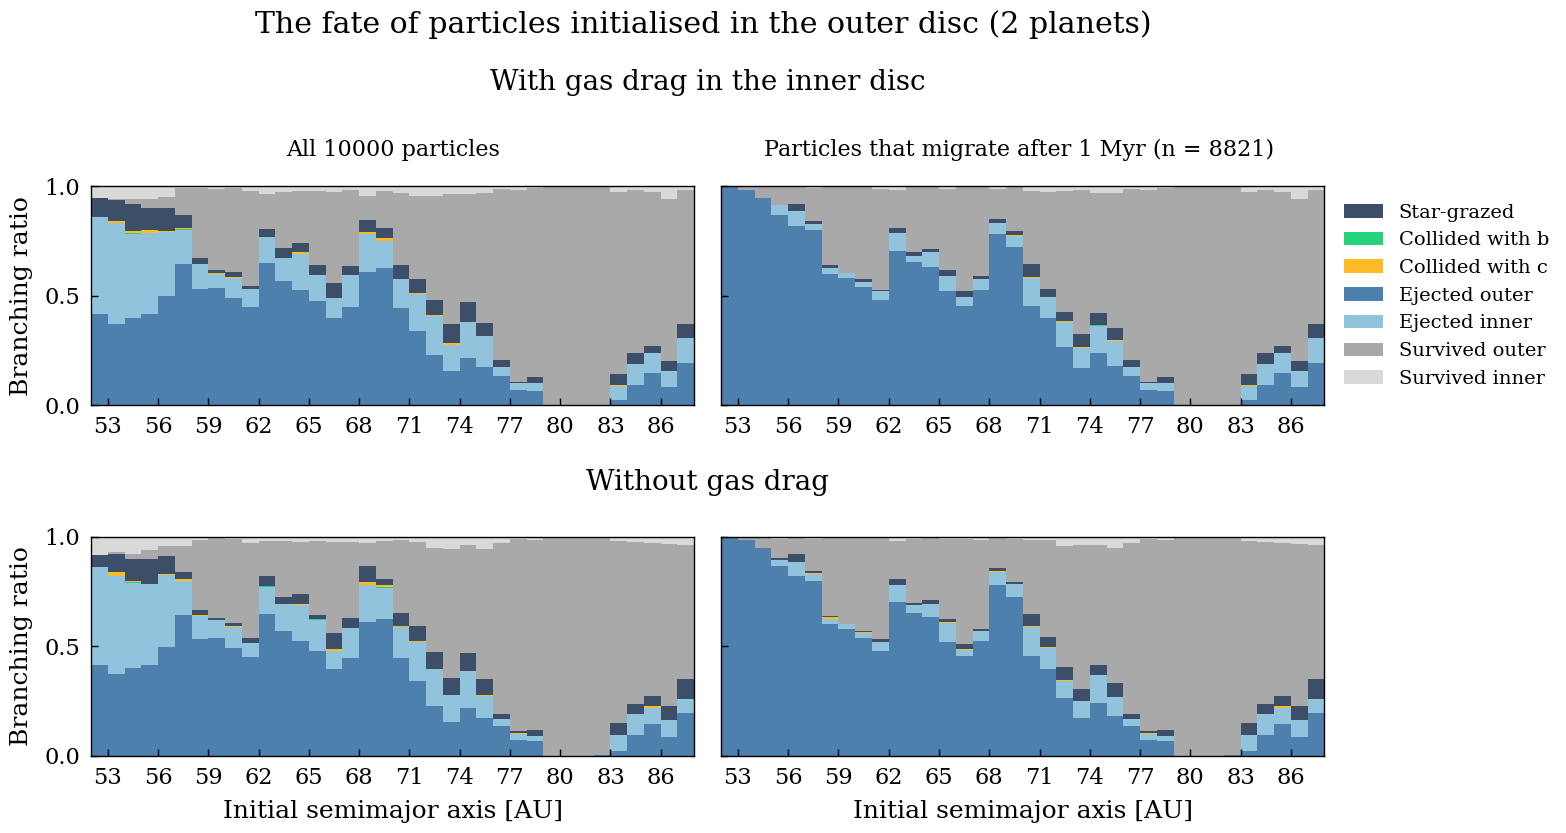

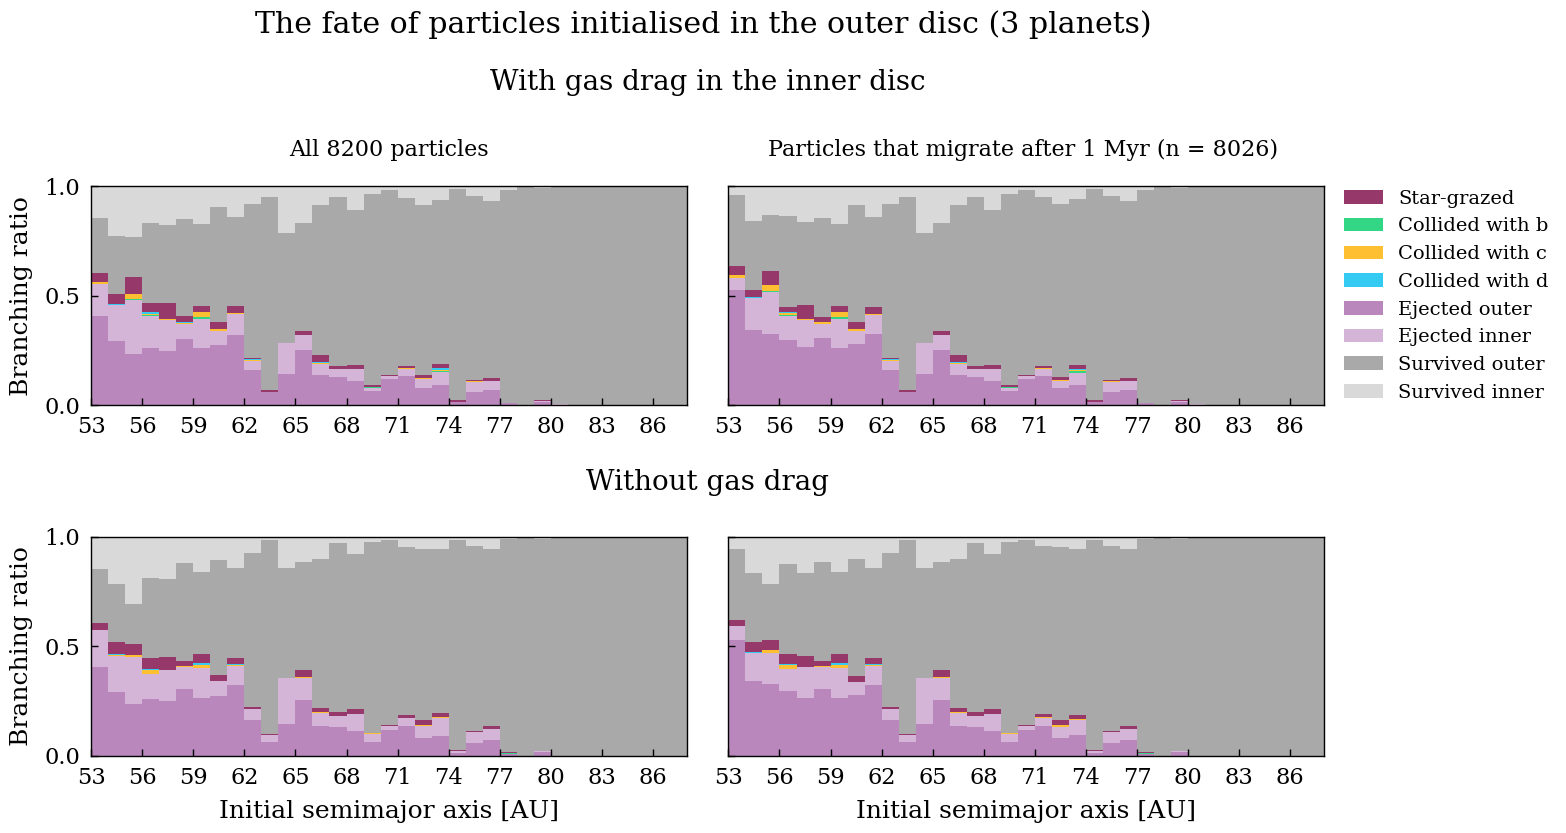

In [22]:
from collections import defaultdict
def get_BR_with_late_mig(combined_files_list, original_file, n_planets):
    """
    Plots branching ratios in 2x2 grid of stacked histograms showing the fate of particles
    as a function of their initial semimajor axis. The panels compare:
        - With vs without gas drag (rows)
        - All particles vs only "mig_later" particles (columns)

    "mig_later" particles are defined as those with migration times > 1e6 (from all_mig_data['time']).

    Parameters
    ----------
    combined_files_list : list
        List of preprocessed simulation outputs for each case (e.g., with and without gas drag).
        Each element should contain dictionaries for ejected, collided, captured, and grazed particles.

    original_file : str or object
        Input data source used to compute the original migration data via
        `plot_outer_disc_particles`.

    n_planets : int
        2 or 3 planets

    titles : list of str
        Titles corresponding to each simulation case (e.g., ["With gas drag", "Without gas drag"]).

    Returns
    -------
    grazed_dict : dict
        Dictionary containing information about star-grazing particles, including their
        associated initial semimajor axes.
    """

    fig, axes = plt.subplots(2, 2, figsize=(16, 8), sharey=True)
    #LOOP THROUGH TWO CASES
    cases = ['all', 'mig_later']

    for row, combined_files in enumerate(combined_files_list):
        for col, case in enumerate(cases):
            ax = axes[row, col]

            #GRAB ALL OLD DATA AND PROCESS IT, WHICH GIVES THESE DICTS
            all_mig_data, ej_dict_first, col_dict_first, capt_dict_first, a_new_first, n_particles = plot_outer_disc_particles(original_file, n_planets, plot=False)


            #DEF MIG LATER PARTICLES
            def filter_mig_data(all_mig_data, mask):
                return {key: [val for val, keep in zip(values, mask) if keep] for key, values in all_mig_data.items()}
            
            def filter_dict_by_hash(d, valid_hashes):
                mask = [int(h) in valid_hashes for h in d['hash']]
                return {k: [v[i] for i in range(len(mask)) if mask[i]] for k, v in d.items()}
        
            if case == 'mig_later':
                mig_mask = np.array(all_mig_data['time']) > 1e6
                all_mig_filtered_data = filter_mig_data(all_mig_data, mig_mask)
            else:
                all_mig_filtered_data = all_mig_data

            valid_hashes = set(all_mig_filtered_data['hash'])
            print(len(valid_hashes))

            hash_to_index = {
                    h: i for i, h in enumerate(all_mig_filtered_data['hash'])
                }

            #GRAB ALL NEW DATA (PRE-PROCESSED)
            ej_data = combined_files[1]
            col_data = combined_files[2]
            capt_data = combined_files[3]
            grazed_data = combined_files[4]

            #MAKE IT PRETTY
            ej_dict = {k: [float(x) for x in v] for k, v in ej_data.items()}
            col_dict = {k: [float(x) for x in v] for k, v in col_data.items()}
            capt_dict = {k: [float(x) for x in v] for k, v in capt_data.items()}    
            grazed_dict = {k: [float(x) for x in v] for k, v in grazed_data.items()}

            #FILTER IN CASE OF MIG_LATER SCENARIO
            ej_dict = filter_dict_by_hash(ej_dict, valid_hashes)
            col_dict = filter_dict_by_hash(col_dict, valid_hashes)
            capt_dict = filter_dict_by_hash(capt_dict, valid_hashes)
            grazed_dict = filter_dict_by_hash(grazed_dict, valid_hashes)

            #GRAB ALL HASHES OF INTERESTING PARTICLES
            # ej_hashes = np.array(ej_dict['hash'])
            # col_hashes = np.array(col_dict['hash'])
            # capt_hashes = np.array(capt_dict['hash'])
            # grazed_hashes = np.array(grazed_dict['hash'])
            all_bad_hashes = np.concatenate([
                    ej_dict['hash'], col_dict['hash'],
                    capt_dict['hash'], grazed_dict['hash']
                ])
            
            #GET INITIAL SEMIMAJOR AXIS OF STABLE PARTICLES
            _, a_new = zip(*[(hashval, aval) for hashval, aval in zip(all_mig_filtered_data['hash'], all_mig_filtered_data['initial_a']) if hashval not in all_bad_hashes])
            
            #fOR EACH DICT, ADD A NEW ENTRY CALLED INITIAL_A FOR MAPPING. THEN, FIND THE CORRESPONDING INDEX!!
            for dictio in [ej_dict, col_dict, capt_dict, grazed_dict]:
                dictio['initial_a'] = [0] * len(dictio['hash'])
                for i, hval in enumerate(dictio['hash']):
                    if int(hval) in hash_to_index:
                        index = hash_to_index[int(hval)]
                        dictio['initial_a'][i] = all_mig_filtered_data['initial_a'][index]

            #MERGE COL/CAPT_FIRST AND COL/CAPT, WE DON'T CARE WHEN IT HAPPENS
            for d, d_first in [(col_dict, col_dict_first), (capt_dict, capt_dict_first)]:
                for key in d_first:
                    if key in d:
                        d[key].extend(d_first[key])
                    else:
                        d[key] = d_first[key]

            # GET PLANET HASHES
            pb = rebound_hash('pb').value
            pc = rebound_hash('pc').value
            pd = rebound_hash('pd').value
            star = rebound_hash('star').value

            # SEPARATE DICTS BY TARGET
            collided_with = {'b': [], 'c': [], 'd': [], 'star': []}
            captured_by = {'b': [], 'c': [], 'd': []}

            # SEPARATE COLLISIONS
            for i, planet_hash in enumerate(col_dict['planet']):
                target = int(planet_hash)
                
                #FLOATS AREN'T SAVED WITH ENOUGH SIG. FIGURES
                if abs(target - pb) < 100:
                    collided_with['b'].append(col_dict['initial_a'][i])
                elif abs(target - pc) < 100:
                    collided_with['c'].append(col_dict['initial_a'][i])
                elif abs(target - pd) < 100:
                    collided_with['d'].append(col_dict['initial_a'][i])
                elif abs(target - star) < 100:
                    collided_with['star'].append(col_dict['initial_a'][i])
                else:
                    print('Error! Hash is none of the above')

            # SEPARATE CAPTURES
            for i, planet_hash in enumerate(capt_dict['planet']):
                target = int(planet_hash)
                if abs(target - pb) < 100:
                    captured_by['b'].append(capt_dict['initial_a'][i])
                elif abs(target - pc) < 100:
                    captured_by['c'].append(capt_dict['initial_a'][i])
                elif abs(target - pd) < 100:
                    captured_by['d'].append(capt_dict['initial_a'][i])
                else:
                    print('Error! Hash is none of the above')
            
            
            spacing = 1
            bins = np.arange(52, 89, spacing)

            # HISTOGRAM TIME
            ejected_counts, _ = np.histogram(ej_dict['initial_a'], bins=bins)
            ejected_counts_first, _ = np.histogram(ej_dict_first['initial_a'], bins=bins)
            col_b_counts, _ = np.histogram(collided_with['b'], bins=bins)
            col_c_counts, _ = np.histogram(collided_with['c'], bins=bins)
            col_d_counts, _ = np.histogram(collided_with['d'], bins=bins)
            col_star_counts, _ = np.histogram(collided_with['star'], bins=bins)
            capt_b_counts, _ = np.histogram(captured_by['b'], bins=bins)
            capt_c_counts, _ = np.histogram(captured_by['c'], bins=bins)
            capt_d_counts, _ = np.histogram(captured_by['d'], bins=bins)
            grazed_counts, _ = np.histogram(grazed_dict['initial_a'], bins=bins)
            all_others, _ = np.histogram(a_new, bins=bins)
            stable_first, _ = np.histogram(a_new_first, bins=bins)

            # STACK IN WHATEVER ORDER YOU WANT
            if n_planets==3:
                stacked_counts = np.vstack([ejected_counts_first, ejected_counts, col_b_counts, col_c_counts, col_d_counts, col_star_counts,
                                            capt_b_counts, capt_c_counts, capt_d_counts,
                                            grazed_counts, stable_first, all_others])
            elif n_planets==2:
                stacked_counts = np.vstack([ejected_counts_first, ejected_counts, col_b_counts, col_c_counts, col_star_counts,
                                            capt_b_counts, capt_c_counts,
                                            grazed_counts, stable_first, all_others])
            
            bin_sums = stacked_counts.sum(axis=0)
            stacked_counts = stacked_counts / bin_sums
            print('all particles plotted:', np.sum(bin_sums))

            
            bin_widths = np.diff(bins)
            x = bins[:-1]

            # PLOTTING TIME

            # Color scheme based on n_planets
            if n_planets == 3:
                colors = {
                    'ejected_first':  "#A969AD",  # kept same light purple
                    'col_b' : "#00CC66",   # vivid green (clean, bright)
                    'col_c' : "#FFB000" ,  # amber (better than yellow, less washed out)
                    'col_d' :"#00BFEF" ,    # rose pink
                    'col_star': '#b22222',  # firebrick red (distinct from purples)
                    'capt_b': '#4a72b0',    # medium blue
                    'capt_c': '#2a9d8f',    # teal
                    'capt_d': '#56b4e9',    # sky blue
                    'grazed': '#841550FF',  # kept same deep pinkish-purple
                    'survived': 'lightgrey',
                    'stable_first': 'darkgrey',
                    'ejected': "#CAA1CD",  # kept same
                }
            elif n_planets == 2:
                    colors = {
                'ejected':  "#77b4d4",    # kept same medium blue
                'col_b' : "#00CC66",   # vivid green (clean, bright)
                'col_c' : "#FFB000" ,  # amber (better than yellow, less washed out)
                'col_star': '#b8860b',    # dark goldenrod (distinct from greens)
                'capt_b': '#0f52ba',      # sapphire blue
                'capt_c': '#00a1b0',      # vibrant cyan-teal
                'grazed': '#1a2f4e',      # navy blue (darker, distinct)
                'stable_first': 'darkgrey',
                'survived': 'lightgrey',
                'ejected_first':  "#206197",
            }

            # PLOT WITH CUMULATIVE BOTTOM
            bottom = np.zeros(len(x))

            # EJECTED (OUTER AND INNER)
            if np.nansum(stacked_counts[0]) > 0:
                ax.bar(x, stacked_counts[0], width=bin_widths, bottom=bottom,
                        alpha=0.8, label="Ejected outer", color=colors['ejected_first'], align='edge', rasterized=True)
                bottom += stacked_counts[0]

            if np.nansum(stacked_counts[1]) > 0:
                ax.bar(x, stacked_counts[1], width=bin_widths, bottom=bottom,
                        alpha=0.8, label="Ejected inner", color=colors['ejected'], align='edge', rasterized=True)
                bottom += stacked_counts[1]

            if n_planets == 3:
                # COLLISIONS
                for i, (label, count_idx) in enumerate([('Collided with b', 2), ('Collided with c', 3), 
                                                        ('Collided with d', 4), ('Collided with star', 5)]):
                    if np.nansum(stacked_counts[count_idx]) > 0:
                        ax.bar(x, stacked_counts[count_idx], width=bin_widths, bottom=bottom,
                                alpha=0.8, label=label, color=colors[f'col_{label.split()[-1]}'], align='edge', rasterized=True)
                        bottom += stacked_counts[count_idx]
                
                # CAPTURES
                for i, (label, count_idx) in enumerate([('Captured by b', 6), ('Captured by c', 7), ('Captured by d', 8)]):
                    if np.nansum(stacked_counts[count_idx]) > 0:
                        ax.bar(x, stacked_counts[count_idx], width=bin_widths, bottom=bottom,
                                alpha=0.8, label=label, color=colors[f'capt_{label.split()[-1]}'], align='edge', rasterized=True)
                        bottom += stacked_counts[count_idx]
        
                # RESONANCES
                # for i, (label, res) in enumerate(res_dict_c_3_pl.items()):
                #     if i == 0:
                #         ax.axvline(res, color=colors['col_c'], linestyle='--', alpha=1, label='Resonance with c')
                #         ax.text(res, 1.01, label, rotation=60, verticalalignment='bottom', horizontalalignment='center', fontsize=14, color=colors['col_c'])

                #     else:
                #         ax.axvline(res, color=colors['col_c'], linestyle='--', alpha=1)
                #         ax.text(res, 1.01, label, rotation=60, verticalalignment='bottom', horizontalalignment='center', fontsize=14, color=colors['col_c'])
                        
                
            elif n_planets == 2:

                # COLLISIONS
                for i, (label, count_idx) in enumerate([('Collided with b', 2), ('Collided with c', 3), ('Collided with star', 4)]):
                    if np.nansum(stacked_counts[count_idx]) > 0:
                        ax.bar(x, stacked_counts[count_idx], width=bin_widths, bottom=bottom,
                                alpha=0.85, label=label, color=colors[f'col_{label.split()[-1]}'], align='edge', rasterized=True)
                        bottom += stacked_counts[count_idx]
    
                # CAPTURES
                for i, (label, count_idx) in enumerate([('Captured by b', 5), ('Captured by c', 6)]):
                    if np.nansum(stacked_counts[count_idx]) > 0:
                        ax.bar(x, stacked_counts[count_idx], width=bin_widths, bottom=bottom,
                                alpha=0.85, label=label, color=colors[f'capt_{label.split()[-1]}'], align='edge', rasterized=True)
                        bottom += stacked_counts[count_idx]

                # RESONANCES
                # for i, (label, res) in enumerate(res_dict_c_2_pl.items()):
                #     if i == 0:
                #         ax.axvline(res, color=colors['col_c'], linestyle='--', alpha=1, label='Resonance with c')
                #         ax.text(res, 1.01, label, rotation=60, verticalalignment='bottom', horizontalalignment='center', fontsize=14, color=colors['col_c'])
                #     else:
                #         ax.axvline(res, color=colors['col_c'], linestyle='--', alpha=1)
                #         ax.text(res, 1.01, label, rotation=60, verticalalignment='bottom', horizontalalignment='center', fontsize=14, color=colors['col_c'])
                    
            # STAR-GRAZED
            if np.nansum(stacked_counts[-3]) > 0:
                ax.bar(x, stacked_counts[-3], width=bin_widths, bottom=bottom,
                        alpha=0.85, label='Star-grazed', color=colors['grazed'], align='edge', rasterized=True)
                bottom += stacked_counts[-3]

            # SURVIVED (INNER AND OUTER)
            if np.nansum(stacked_counts[-2]) > 0:
                ax.bar(x, stacked_counts[-2], width=bin_widths, bottom=bottom,
                        alpha=1, label="Survived outer", color=colors['stable_first'], align='edge', rasterized=True)
                bottom += stacked_counts[-2]

            if np.nansum(stacked_counts[-1]) > 0:
                ax.bar(x, stacked_counts[-1], width=bin_widths, bottom=bottom,
                        alpha=0.85, label="Survived inner", color=colors['survived'], align='edge', rasterized=True)

            # ADD TEXT FOR NUMBER OF PARTICLES IN EACH BIN                
            # for i in range(len(x)):
            #     ax.text(x[i]+bin_widths[i]/2, 1, str(int(bin_sums[i])),
            #         ha='center', va='bottom', fontsize=12)
            
            
            # TICKS
            ax.minorticks_off()
            tick_idx = np.arange(1, len(bins), 3)
            ax.set_xticks(bins[tick_idx])
            ax.set_xticklabels([f"{b:.0f}" for b in bins[tick_idx]])

            #axes[1].text(90, 0.87, rf'{n_particles} particles', color='k', ha='left', fontsize=15)

            # LABELS AND TITLES
            
            #axes[0].set_ylabel('Branching ratio')
            if col == 0 and row == 0:
                ax.set_title(f'All {n_particles} particles', fontsize=16, y=1.1)

            if row == 1:
                ax.set_xlabel('Initial semimajor axis [AU]')
            
            if col == 1 and row == 0:
                ax.set_title(f'Particles that migrate after 1 Myr (n = {(np.sum(bin_sums))}) ', fontsize=16, y=1.1)

            if col == 0:
                ax.set_ylabel('Branching ratio')

            plt.suptitle(f'The fate of particles initialised in the outer disc ({n_planets} planets)', y=1.05, x=0.45)
            
            # LEGEND ON THE OUTSIDE

            handles, labels = ax.get_legend_handles_labels()

            if n_planets == 3:
                order = [5, 2, 3, 4, 0, 1, 6, 7]
            else:
                order = [4, 2, 3, 0, 1, 5, 6]  # new order (indices)

            if row==0 and col==1:
                ax.legend(
                    [handles[i] for i in order],
                    [labels[i] for i in order],
                    loc='center left',
                    bbox_to_anchor=(1.02, 0.5),
                    borderaxespad=0,
                    frameon=False,
                    fontsize=14  # Slightly smaller due to more legend items
                )

    plt.tight_layout()
    fig.subplots_adjust(hspace=0.6)
   
    left = min(ax.get_position().x0 for ax in axes.flatten())
    right = max(ax.get_position().x1 for ax in axes.flatten())

    center_x = (left + right) / 2
    fig.text(center_x, 0.96, "With gas drag in the inner disc", ha='center', va='center', fontsize=20)
    fig.text(center_x, 0.46, "Without gas drag", ha='center', va='center', fontsize=20)
    
    
    plt.savefig(f'plots/final_branching_ratio_with_late_mig_{n_planets}.png', bbox_inches='tight')
    plt.savefig(f'plots/final_branching_ratio_with_late_mig_{n_planets}.pdf', bbox_inches='tight')
    #plt.show()
    return grazed_dict


get_BR_with_late_mig([two_planet_all_files, two_pl_no_gd_all_files], two_pl_files_new, 2)
get_BR_with_late_mig([three_planet_all_files, three_pl_no_gd_all_files], three_pl_files_new, 3)

## Case study of an orbit

First, grab the hashes of the interesting particles

In [ ]:
def get_grazed_data(gas_drag_file, outer_disc_file, n_planets):

    all_mig_data = plot_outer_disc_particles(outer_disc_file, n_planets, plot=False)[0]

    grazed_data = gas_drag_file[4]
    grazed_dict = {k: [float(x) for x in v] for k, v in grazed_data.items()}

    grazed_dict['initial_a'] = [0] * len(grazed_dict['hash'])

    for i, hash in enumerate(grazed_dict['hash']):
        index_grazed = all_mig_data['hash'].index(int(hash))
        initial_semimajoraxis_grazed = all_mig_data['initial_a'][index_grazed]
        grazed_dict['initial_a'][i] = initial_semimajoraxis_grazed

    indices = [i for i, a in enumerate(grazed_dict['initial_a']) if a > 80]
    
    hash_vals = [grazed_dict['hash'][i] for i in indices]

    return hash_vals

hashes = get_grazed_data(two_planet_all_files, two_pl_files_new, 2)
print(len(hashes))

In [ ]:
def get_parameters_from_hash(filenames, hash_list, n_planets, newformat = True):
    '''
    Get parameters of specific particles (by hash)
    '''

    params = ['time', 'x', 'y', 'z', 'hash']
    all_data = {param: [] for param in params}
    all_pl_b_data = {param: [] for param in params}
    all_pl_c_data = {param: [] for param in params}
    hash_to_mig_time = {}
    all_mig_times = []
    
    for index, file in enumerate(filenames):
        
        with netCDF4.Dataset(file, 'r') as ncfile:
            # Read migration data
            mig_data = ncfile['migrated_peri'][:]
            if mig_data.size > 0:
                mig_times = mig_data[:, 0].compressed()
                mig_hashes = mig_data[:, -1].compressed().astype(int)
                for t, h in zip(mig_times, mig_hashes):
                    hash_to_mig_time[h] = t
            
            hashes = ncfile['test_particles'][0, n_planets:, -1].astype(int)
            mask = np.isin(hashes, hash_list)

            all_times = ncfile['test_particles'][:, n_planets:, :]
            selected = all_times[:, mask, :]  # [time, selected_particles, param]
            
            if selected.shape[1] > 0:  # if any selected
                for i in range(selected.shape[1]):
                    planet_data = ncfile['test_particles'][:, :n_planets, :]
                    particle_data = selected[:, i, :]  # [time, param]
                    time_array = particle_data[:, 0]
                    hash_val = int(particle_data[0, -1])
                    mig_time = hash_to_mig_time.get(hash_val, np.inf)
                    all_mig_times.append(mig_time)
                    valid_mask = time_array <= mig_time
                    all_pl_b_data['x'].append(planet_data[valid_mask, 0, 1])
                    all_pl_b_data['y'].append(planet_data[valid_mask, 0, 2])
                    all_pl_b_data['z'].append(planet_data[valid_mask, 0, 3])
                    all_pl_c_data['x'].append(planet_data[valid_mask, 1, 1])
                    all_pl_c_data['y'].append(planet_data[valid_mask, 1, 2])
                    all_pl_c_data['z'].append(planet_data[valid_mask, 1, 3])
                    all_data['time'].append(time_array[valid_mask])
                    all_data['x'].append(particle_data[valid_mask, 1])
                    all_data['y'].append(particle_data[valid_mask, 2])
                    all_data['z'].append(particle_data[valid_mask, 3])
                    all_data['hash'].append(hash_val)

    print(all_data, all_pl_b_data, all_pl_c_data)


    for i, hash_val in enumerate(all_data['hash']):
        pattern = f"core_outputs_yr2/gas_drag/*{hash_val:.0f}_2_pl_single_particle_2.nc"
        f_gas_drag = glob.glob(pattern)
        if f_gas_drag:
            file = f_gas_drag[0]
            with netCDF4.Dataset(file, 'r') as ncfile:
                all_times = ncfile['test_particles'][:]  
                all_times = np.where(np.abs(all_times) > 1e30, np.nan, all_times)
                time_array = all_times[:, 0]
                adjusted_times = time_array + all_mig_times[i]
                all_data['time'][i] = np.concatenate([all_data['time'][i], adjusted_times])
                all_data['x'][i] = np.concatenate([all_data['x'][i], all_times[:,1]])
                all_data['y'][i] = np.concatenate([all_data['y'][i], all_times[:,2]])
                all_data['z'][i] = np.concatenate([all_data['z'][i], all_times[:,3]])
                all_pl_b_data['x'][i] = np.concatenate([all_pl_b_data['x'][i], ncfile['massive_bodies'][:, 1, 1]])
                all_pl_b_data['y'][i] = np.concatenate([all_pl_b_data['y'][i], ncfile['massive_bodies'][:, 1, 2]])
                all_pl_b_data['z'][i] = np.concatenate([all_pl_b_data['z'][i], ncfile['massive_bodies'][:, 1, 3]])
                all_pl_c_data['x'][i] = np.concatenate([all_pl_c_data['x'][i], ncfile['massive_bodies'][:, 2, 1]])
                all_pl_c_data['y'][i] = np.concatenate([all_pl_c_data['y'][i], ncfile['massive_bodies'][:, 2, 2]])
                all_pl_c_data['z'][i] = np.concatenate([all_pl_c_data['z'][i], ncfile['massive_bodies'][:, 2, 3]])

    return all_data, all_pl_b_data, all_pl_c_data, all_mig_times

particles, pb, pc, mig_time = get_parameters_from_hash(two_pl_files_new, hashes, 2)
print(particles['x'][0].shape)
print(len(particles['x'][1]))
# Plot orbits
for n, i in enumerate(range(len(particles['hash'][:]))):
    fig, ax = plt.subplots(figsize=(8, 6))

    ax.plot(particles['x'][i], particles['y'][i], linestyle='', marker='o', markersize=1,) #label=f"Hash {particles['hash'][i]}")
    ax.plot(pb['x'][i], pb['y'][i], linestyle='-', marker='', c='orange', label='Planet b')
    ax.plot(pc['x'][i], pc['y'][i], linestyle='-', marker='', c='green', label='Planet c')
    ax.set_xlabel('x (AU)')
    ax.set_ylabel('y (AU)')

    last_val_x = particles['x'][i][~np.isnan(particles['x'][i])][-1]
    last_val_y = particles['y'][i][~np.isnan(particles['y'][i])][-1]
    ax.plot(last_val_x, last_val_y, linestyle='', marker='o', c='blue', markersize=5, label='Star-grazed point')
    ax.set_title(f'Orbits of Particle {n}, mig at = {mig_time[n]}')
    ax.legend()
    plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
from matplotlib.collections import LineCollection

# --- Load your particle data ---
test_ptcl = 1
x_all = particles['x'][test_ptcl]
y_all = particles['y'][test_ptcl]
x_pb_all = pb['x'][test_ptcl]
y_pb_all = pb['y'][test_ptcl]
x_pc_all = pc['x'][test_ptcl]
y_pc_all = pc['y'][test_ptcl]


# --- Stop at first NaN ---
nan_mask = np.isnan(x_all) | np.isnan(y_all)
nan_indices = np.where(nan_mask)[0]

if len(nan_indices) > 0:
    stop_idx = nan_indices[0]
else:
    stop_idx = len(x_all)

x_all = x_all[:stop_idx]
y_all = y_all[:stop_idx]
xplall = x_pb_all[:stop_idx]
yplall = y_pb_all[:stop_idx]
xpcall = x_pc_all[:stop_idx]
ypcall = y_pc_all[:stop_idx]

# --- Figure setup ---
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_xlim(-100, 100)
ax.set_ylim(-100, 100)
ax.set_xlabel('x (AU)')
ax.set_ylabel('y (AU)')
ax.set_title('Animation of Grazed Particle Orbit')

# --- LineCollection for fading trail ---
line = LineCollection([], linewidths=2)
ax.add_collection(line)

# --- LineCollection for planet trails ---
line_b = LineCollection([], linewidths=2)
ax.add_collection(line_b)
line_c = LineCollection([], linewidths=2)
ax.add_collection(line_c)

point, = ax.plot([], [], marker='o', markersize=6, color='blue',  label='Particle')
pointb, = ax.plot([], [], marker='o', markersize=6, color='red', label='Planet b')
pointc, = ax.plot([], [], marker='o', markersize=6, color='green', label='Planet c')

ax.legend()
# --- Animation parameters ---
tail_length = 200  # number of points in the trail

def init():
    line.set_segments([])
    line_b.set_segments([])
    line_c.set_segments([])
    point.set_data([], [])
    pointb.set_data([], [])
    pointc.set_data([], [])

    return [line, line_b, line_c, point, pointb, pointc]

def animate(frame):
    start = max(0, frame - tail_length)

    x_data = x_all[start:frame]
    y_data = y_all[start:frame]
    x_pl_data = xplall[start:frame]
    y_pl_data = yplall[start:frame]
    x_pc_data = xpcall[start:frame]
    y_pc_data = ypcall[start:frame]

    # Particle trail and point
    if len(x_data) >= 2:
        points = np.array([x_data, y_data]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        alphas = np.linspace(0.1, 1.0, len(segments))
        colors = [(0, 0, 1, a) for a in alphas]  # blue fading
        line.set_segments(segments)
        line.set_color(colors)
    else:
        line.set_segments([])
    point.set_data([x_all[frame]], [y_all[frame]])

    # Planet B trail and point
    if len(x_pl_data) >= 2:
        points_b = np.array([x_pl_data, y_pl_data]).T.reshape(-1, 1, 2)
        segments_b = np.concatenate([points_b[:-1], points_b[1:]], axis=1)
        alphas_b = np.linspace(0.1, 1.0, len(segments_b))
        colors_b = [(1, 0, 0, a) for a in alphas_b]  # red fading
        line_b.set_segments(segments_b)
        line_b.set_color(colors_b)
    else:
        line_b.set_segments([])
    pointb.set_data([x_pb_all[frame]], [y_pb_all[frame]])

    # Planet C trail and point
    if len(x_pc_data) >= 2:
        points_c = np.array([x_pc_data, y_pc_data]).T.reshape(-1, 1, 2)
        segments_c = np.concatenate([points_c[:-1], points_c[1:]], axis=1)
        alphas_c = np.linspace(0.1, 1.0, len(segments_c))
        colors_c = [(0, 1, 0, a) for a in alphas_c]  # green fading
        line_c.set_segments(segments_c)
        line_c.set_color(colors_c)
    else:
        line_c.set_segments([])
    pointc.set_data([x_pc_all[frame]], [y_pc_all[frame]])

    return [line, line_b, line_c, point, pointb, pointc]

# --- Frame handling ---
n_frames_total = len(x_all)
print(n_frames_total)

max_frames = 600
step = max(1, n_frames_total // max_frames)
frames = range(2000, n_frames_total, step)

# --- Create animation ---
anim = FuncAnimation(
    fig,
    animate,
    init_func=init,
    frames=frames,
    interval=50,
    blit=True
)

# --- Save animation ---
writer = FFMpegWriter(fps=10)
anim.save(f'animations/grazed_particles_animation_ptcl_{test_ptcl}.mp4', writer=writer)

plt.close(fig)

In [ ]:
# Animation of orbits
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_xlim(-100, 100)  # adjust based on data
ax.set_ylim(-100, 100)
ax.set_xlabel('x (AU)')
ax.set_ylabel('y (AU)')
ax.set_title('Animation of Grazed Particles Orbits')

lines = []
line, = ax.plot([], [])
lines.append(line)

ax.legend()

def init():
    for line in lines:
        line.set_data([], [])
    return lines

def animate(frame):
    x_data = particles['x'][1][100:frame+1]
    y_data = particles['y'][1][100:frame+1]
    line.set_data(x_data, y_data)
    return lines

# Assuming all particles have the same number of time steps
n_frames_total = len(particles['x'][0]) if particles['x'] else 0
max_frames = 600  # 30 seconds at 50ms per frame
step = max(1, n_frames_total // max_frames)
frames = range(0, n_frames_total, step)

writervideo = animation.FFMpegWriter(fps=60)
anim = FuncAnimation(fig, animate, init_func=init, frames=frames, interval=50, blit=True)

anim.save('animations/grazed_particles_animation_ptcl_1.mp4', writer=writervideo)

# When do particles star-graze?

In [ ]:
all_sg_particles_2pl = two_planet_all_files[4]
times_2pl = np.array(all_sg_particles_2pl['time']) / 1e6

all_sg_particles_3pl = three_planet_all_files[4]
times_3pl = np.array(all_sg_particles_3pl['time']) / 1e6

fig, ax = plt.subplots(1, 2, figsize=(14,5), sharey=True)
myblue = "#487ac5"
mypink = "#841550FF" # darker purple

ax[0].hist(times_2pl,  bins=20, color=myblue, alpha=0.9,
        weights= np.ones_like(all_sg_particles_2pl['time'])/len(all_sg_particles_2pl['time'])*100,
        cumulative=False, label=r'star-grazed ($R_p < 0.4$ AU)')
ax[1].hist(times_3pl, bins=20, color=mypink, alpha=0.9,
        weights= np.ones_like(all_sg_particles_3pl['time'])/len(all_sg_particles_3pl['time'])*100,
        cumulative=False, label=r'star-grazed ($R_p < 0.4$ AU)')

for i in range(ax.shape[0]):
    ax[i].set_xlabel('Time [Myr]')
    ax[i].set_title(f'{i+2} planets')
    ax[i].legend()
    ax[i].minorticks_off()

    #ax[i].set_xscale('log')

ax[0].set_ylabel('Percentage of star-grazers')
plt.show()